# Imports and configs

In [19]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.spatial.transform import Rotation as R

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier

import torch
import torch.nn as nn

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = ['MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import warnings
import optuna
import joblib
import glob
import gc
import time
from tqdm import tqdm
import os

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 5
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Data loading

In [80]:
train = pd.read_csv(CFG.train_path).reset_index(drop=True)
train_d = pd.read_csv(CFG.train_demographic_path).reset_index(drop=True)
test = pd.read_csv(CFG.test_path).reset_index(drop=True)
test_d = pd.read_csv(CFG.test_demographic_path).reset_index(drop=True)

# Preprocessing

In [81]:
le_gesture = LabelEncoder()
train["e_gesture"] = le_gesture.fit_transform(train["gesture"])

In [82]:
# rotが欠損しているsequenceは除外
rot_cols = [col for col in train.columns if col.startswith('rot_')]

rot_null_row_train = train[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_train = train.loc[rot_null_row_train, 'sequence_id'].unique()
rot_null_row_test = test[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_test = test.loc[rot_null_row_test, 'sequence_id'].unique()

train = train[~train['sequence_id'].isin(rot_null_sequence_ids_train)].reset_index(drop=True)
test = test[~test['sequence_id'].isin(rot_null_sequence_ids_test)].reset_index(drop=True)

print(f"=== rot null sequence count ===")
print(f"train: {len(rot_null_sequence_ids_train)}")
print(f"test: {len(rot_null_sequence_ids_test)}")


=== rot null sequence count ===
train: 50
test: 0


In [83]:
# thm, tofのいずれか1つでもNaNがあればIMU-only
thm_cols = [col for col in train.columns if col.startswith('thm_')]
tof_cols = [col for col in train.columns if col.startswith('tof_')]

thm_null_row_train = train[thm_cols].isnull().any(axis=1)
thm_null_sequence_ids_train = train.loc[thm_null_row_train, 'sequence_id'].unique()

print(f"thm null sequence count: {len(thm_null_sequence_ids_train)}")

tof_null_row_train = train[tof_cols].isnull().any(axis=1)
tof_null_sequence_ids_train = train.loc[tof_null_row_train, 'sequence_id'].unique()

print(f"tof null sequence count: {len(tof_null_sequence_ids_train)}")

imu_only_seq_ids = list(set(thm_null_sequence_ids_train) | set(tof_null_sequence_ids_train))
full_data_seq_ids = train[~train['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].unique()

# Set thermal and ToF columns to NaN for IMU-only sequences
train.loc[train['sequence_id'].isin(imu_only_seq_ids), thm_cols+tof_cols] = np.nan

print(f"imu only seq count: {len(imu_only_seq_ids)}")
print(f"full data seq count: {len(full_data_seq_ids)}")

thm null sequence count: 508
tof null sequence count: 435
imu only seq count: 508
full data seq count: 7593


In [84]:
# full dataからimu only用のデータを作成
train_imu_only = train.copy()
train_imu_only[thm_cols+tof_cols] = np.nan

train_imu_only.isnull().sum()

row_id                   0
sequence_type            0
sequence_id              0
sequence_counter         0
subject                  0
                     ...  
tof_5_v60           571253
tof_5_v61           571253
tof_5_v62           571253
tof_5_v63           571253
e_gesture                0
Length: 342, dtype: int64

In [85]:
def create_balanced_lightweight_dataset(train, sequences_per_gesture=100):
    """
    各ジェスチャーから指定数のシーケンスをバランス良く抽出
    """
    print("=== バランス軽量化データセット作成 ===")
    
    selected_sequences = []
    gesture_info = []
    
    # 各ジェスチャーから指定数のシーケンスを選択
    for gesture in le_gesture.classes_:
        # 該当ジェスチャーのシーケンスID取得
        gesture_sequences = train[train['gesture'] == gesture]['sequence_id'].unique()
        available_count = len(gesture_sequences)
        
        print(f"{gesture}: {available_count} sequences available")
        
        # 指定数まで選択（利用可能数が少ない場合は全て選択）
        n_to_select = min(sequences_per_gesture, available_count)
        
        # ランダムサンプリング（再現性のため乱数シード固定）
        np.random.seed(CFG.seed)
        selected = np.random.choice(gesture_sequences, n_to_select, replace=False)
        selected_sequences.extend(selected)
        
        gesture_info.append({
            'gesture': gesture,
            'available': available_count,
            'selected': n_to_select
        })
    
    # 選択されたシーケンスでデータを絞り込み
    train_balanced = train[train['sequence_id'].isin(selected_sequences)].copy()
    
    # 結果サマリー
    print(f"\n=== 軽量化結果 ===")
    print(f"総シーケンス数: {len(selected_sequences)}")
    print(f"元データからの削減率: {(1 - len(selected_sequences)/len(train['sequence_id'].unique())):.1%}")
    
    # ジェスチャー別サマリー
    gesture_summary = pd.DataFrame(gesture_info)
    print(f"\nジェスチャー別選択数:")
    for _, row in gesture_summary.iterrows():
        print(f"  {row['gesture']}: {row['selected']}/{row['available']}")
    
    # IMU-only vs Full-sensor比率確認
    imu_sequences = train_balanced[train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    full_sequences = train_balanced[~train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    
    print(f"\n=== センサータイプ分布 ===")
    print(f"IMU-only: {imu_sequences} sequences ({imu_sequences/len(selected_sequences):.1%})")
    print(f"Full-sensor: {full_sequences} sequences ({full_sequences/len(selected_sequences):.1%})")
    
    # 被験者分布確認
    selected_subjects = train_balanced['subject'].nunique()
    total_subjects = train['subject'].nunique()
    print(f"\n=== 被験者分布 ===")
    print(f"対象被験者数: {selected_subjects}/{total_subjects}")
    
    return train_balanced, selected_sequences

In [86]:
# バランス軽量化実行
train_balanced, selected_sequences = create_balanced_lightweight_dataset(
    train, sequences_per_gesture=150
)

=== バランス軽量化データセット作成 ===
Above ear - pull hair: 634 sequences available
Cheek - pinch skin: 633 sequences available
Drink from bottle/cup: 161 sequences available
Eyebrow - pull hair: 634 sequences available
Eyelash - pull hair: 636 sequences available
Feel around in tray and pull out an object: 161 sequences available
Forehead - pull hairline: 636 sequences available
Forehead - scratch: 636 sequences available
Glasses on/off: 161 sequences available
Neck - pinch skin: 636 sequences available
Neck - scratch: 634 sequences available
Pinch knee/leg skin: 161 sequences available
Pull air toward your face: 473 sequences available
Scratch knee/leg skin: 161 sequences available
Text on phone: 636 sequences available
Wave hello: 474 sequences available
Write name in air: 473 sequences available
Write name on leg: 161 sequences available

=== 軽量化結果 ===
総シーケンス数: 2700
元データからの削減率: 66.7%

ジェスチャー別選択数:
  Above ear - pull hair: 150/634
  Cheek - pinch skin: 150/633
  Drink from bottle/cup: 150/161
  E

# Feature Engineering

## IMU

In [11]:
def remove_gravity_from_acc(acc_data, rot_data) -> np.ndarray:

    if isinstance(acc_data, pd.DataFrame):
        acc_values = acc_data[['acc_x', 'acc_y', 'acc_z']].values
    else:
        acc_values = acc_data

    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = acc_values.shape[0]
    linear_accel = np.zeros_like(acc_values)
    
    gravity_world = np.array([0, 0, 9.81])

    for i in range(num_samples):
        if np.all(np.isnan(quat_values[i])) or np.all(np.isclose(quat_values[i], 0)):
            linear_accel[i, :] = acc_values[i, :] 
            continue

        try:
            rotation = R.from_quat(quat_values[i])
            gravity_sensor_frame = rotation.apply(gravity_world, inverse=True)
            linear_accel[i, :] = acc_values[i, :] - gravity_sensor_frame
        except ValueError:
             linear_accel[i, :] = acc_values[i, :]
             
    return linear_accel


def calculate_angular_velocity_from_quat(rot_data, time_delta=1/10) -> np.ndarray: # Assuming 10Hz sampling rate
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_vel = np.zeros((num_samples, 3))

    for i in range(num_samples - 1):
        q_t = quat_values[i]
        q_t_plus_dt = quat_values[i+1]

        if np.all(np.isnan(q_t)) or np.all(np.isclose(q_t, 0)) or \
           np.all(np.isnan(q_t_plus_dt)) or np.all(np.isclose(q_t_plus_dt, 0)):
            continue

        try:
            rot_t = R.from_quat(q_t)
            rot_t_plus_dt = R.from_quat(q_t_plus_dt)

            # Calculate the relative rotation
            delta_rot = rot_t.inv() * rot_t_plus_dt
            
            # Convert delta rotation to angular velocity vector
            # The rotation vector (Euler axis * angle) scaled by 1/dt
            # is a good approximation for small delta_rot
            angular_vel[i, :] = delta_rot.as_rotvec() / time_delta
        except ValueError:
            # If quaternion is invalid, angular velocity remains zero
            pass
            
    return angular_vel


def calculate_angular_distance(rot_data) -> np.ndarray:
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_dist = np.zeros(num_samples)

    for i in range(num_samples - 1):
        q1 = quat_values[i]
        q2 = quat_values[i+1]

        if np.all(np.isnan(q1)) or np.all(np.isclose(q1, 0)) or \
           np.all(np.isnan(q2)) or np.all(np.isclose(q2, 0)):
            angular_dist[i] = 0 # Или np.nan, в зависимости от желаемого поведения
            continue
        try:
            # Преобразование кватернионов в объекты Rotation
            r1 = R.from_quat(q1)
            r2 = R.from_quat(q2)

            # Вычисление углового расстояния: 2 * arccos(|real(p * q*)|)
            # где p* - сопряженный кватернион q
            # В scipy.spatial.transform.Rotation, r1.inv() * r2 дает относительное вращение.
            # Угол этого относительного вращения - это и есть угловое расстояние.
            relative_rotation = r1.inv() * r2
            
            # Угол rotation vector соответствует угловому расстоянию
            # Норма rotation vector - это угол в радианах
            angle = np.linalg.norm(relative_rotation.as_rotvec())
            angular_dist[i] = angle
        except ValueError:
            angular_dist[i] = 0 # В случае недействительных кватернионов
            pass
            
    return angular_dist

In [12]:
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass

@dataclass
class IMUFeatureConfig:
    """IMU特徴量抽出の設定"""
    rolling_windows: List[int] = None
    frequency_bands: int = 4  # 周波数帯域の分割数
    correlation_threshold: float = 1e-8  # 相関計算の閾値
    motion_threshold: float = 1e-8  # 動作強度計算の閾値
    
    def __post_init__(self):
        if self.rolling_windows is None:
            self.rolling_windows = [10, 20]


def create_linear_acceleration_features(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """
    線形加速度特徴量を作成（重力除去）
    
    Returns:
        新しく作成された特徴量の辞書
    """
    features = {}
    
    if not all(col in df.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
        return features
    
    try:
        acc_data = df[['acc_x', 'acc_y', 'acc_z']]
        rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        linear_accel = remove_gravity_from_acc(acc_data, rot_data)
        
        # 線形加速度
        features['linear_acc_x'] = linear_accel[:, 0]
        features['linear_acc_y'] = linear_accel[:, 1]
        features['linear_acc_z'] = linear_accel[:, 2]
        features['linear_acc_mag'] = np.sqrt(
            linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2
        )
        
        # 線形加速度のJerk
        features['linear_acc_jerk_x'] = np.diff(linear_accel[:, 0], prepend=linear_accel[0, 0])
        features['linear_acc_jerk_y'] = np.diff(linear_accel[:, 1], prepend=linear_accel[0, 1])
        features['linear_acc_jerk_z'] = np.diff(linear_accel[:, 2], prepend=linear_accel[0, 2])
        features['linear_acc_jerk_mag'] = np.sqrt(
            features['linear_acc_jerk_x']**2 + 
            features['linear_acc_jerk_y']**2 + 
            features['linear_acc_jerk_z']**2
        )
        
    except Exception as e:
        print(f"線形加速度特徴量作成でエラー: {e}")
    
    return features


def create_global_acceleration_features(df: pd.DataFrame, linear_accel_features: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    """
    グローバル座標系での加速度特徴量を作成
    
    Args:
        df: 元のDataFrame
        linear_accel_features: 線形加速度特徴量
    
    Returns:
        グローバル座標系特徴量の辞書
    """
    features = {}
    
    if 'linear_acc_x' not in linear_accel_features:
        return features
    
    try:
        linear_accel = np.column_stack([
            linear_accel_features['linear_acc_x'],
            linear_accel_features['linear_acc_y'], 
            linear_accel_features['linear_acc_z']
        ])
        
        quat_values = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
        global_acc = np.zeros_like(linear_accel)
        
        for i in range(len(linear_accel)):
            if not np.any(np.isnan(quat_values[i])) and not np.all(np.isclose(quat_values[i], 0)):
                try:
                    rotation = R.from_quat(quat_values[i])
                    global_acc[i] = rotation.apply(linear_accel[i])
                except ValueError:
                    global_acc[i] = linear_accel[i]
            else:
                global_acc[i] = linear_accel[i]
        
        # グローバル座標系での加速度
        features['global_acc_x'] = global_acc[:, 0]
        features['global_acc_y'] = global_acc[:, 1]
        features['global_acc_z'] = global_acc[:, 2]
        features['global_acc_mag'] = np.sqrt(
            global_acc[:, 0]**2 + global_acc[:, 1]**2 + global_acc[:, 2]**2
        )
        
        # グローバル座標系でのJerk
        features['global_acc_jerk_x'] = np.diff(global_acc[:, 0], prepend=global_acc[0, 0])
        features['global_acc_jerk_y'] = np.diff(global_acc[:, 1], prepend=global_acc[0, 1])
        features['global_acc_jerk_z'] = np.diff(global_acc[:, 2], prepend=global_acc[0, 2])
        features['global_acc_jerk_mag'] = np.sqrt(
            features['global_acc_jerk_x']**2 + 
            features['global_acc_jerk_y']**2 + 
            features['global_acc_jerk_z']**2
        )
        
    except Exception as e:
        print(f"グローバル加速度特徴量作成でエラー: {e}")
    
    return features


def create_rotation_features(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """
    回転関連特徴量を作成
    
    Returns:
        回転特徴量の辞書
    """
    features = {}
    
    try:
        # 基本的な回転特徴量
        features['rot_mag'] = np.sqrt(
            df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2
        )
        
        # 角速度計算
        if all(col in df.columns for col in ['rot_x', 'rot_y', 'rot_z', 'rot_w']):
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            angular_velocity = calculate_angular_velocity_from_quat(rot_data)
            
            features['angular_vel_x'] = angular_velocity[:, 0]
            features['angular_vel_y'] = angular_velocity[:, 1]
            features['angular_vel_z'] = angular_velocity[:, 2]
            features['angular_vel_mag'] = np.sqrt(
                angular_velocity[:, 0]**2 + angular_velocity[:, 1]**2 + angular_velocity[:, 2]**2
            )
            
            # 角度距離
            angular_distance = calculate_angular_distance(rot_data)
            features['angular_distance'] = angular_distance
            
    except Exception as e:
        print(f"回転特徴量作成でエラー: {e}")
    
    return features


def create_imu_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    IMUセンサデータから高度なIMU特徴量を作成
    
    Args:
        df: 元のDataFrame（変更されません）
    
    Returns:
        IMU特徴量のみを含む新しいDataFrame
    """
    # 元のDataFrameをコピーして変更を防ぐ
    df_work = df.copy()
    all_features = {}
    
    try:
        # 1. 線形加速度特徴量
        linear_features = create_linear_acceleration_features(df_work)
        all_features.update(linear_features)
        
        # 2. グローバル座標系特徴量
        global_features = create_global_acceleration_features(df_work, linear_features)
        all_features.update(global_features)
        
        # 3. 回転関連特徴量
        rotation_features = create_rotation_features(df_work)
        all_features.update(rotation_features)
        
        # 4. 基本的な加速度特徴量（フォールバック）
        if not linear_features:  # 線形加速度が作成できない場合
            all_features.update({
                'acc_mag': np.sqrt(df_work['acc_x']**2 + df_work['acc_y']**2 + df_work['acc_z']**2),
                'acc_jerk_x': np.diff(df_work['acc_x'], prepend=df_work['acc_x'].iloc[0]),
                'acc_jerk_y': np.diff(df_work['acc_y'], prepend=df_work['acc_y'].iloc[0]),
                'acc_jerk_z': np.diff(df_work['acc_z'], prepend=df_work['acc_z'].iloc[0]),
            })
            all_features['acc_jerk_mag'] = np.sqrt(
                all_features['acc_jerk_x']**2 + 
                all_features['acc_jerk_y']**2 + 
                all_features['acc_jerk_z']**2
            )
        
        # 5. 補完的特徴量
        all_features['raw_acc_mag'] = np.sqrt(
            df_work['acc_x']**2 + df_work['acc_y']**2 + df_work['acc_z']**2
        )
        
        # 6. 基本的な回転データ
        for col in ['rot_x', 'rot_y', 'rot_z', 'rot_w']:
            if col in df_work.columns:
                all_features[col] = df_work[col].values
        
    except Exception as e:
        print(f"IMU特徴量作成でエラー: {e}")
        # フォールバック: 基本的なIMU列のみ返す
        base_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]
        return df[base_cols].copy()
    
    # DataFrameに変換
    result_df = pd.DataFrame(all_features)
    return result_df

In [45]:
def calculate_statistical_imu_features(arr: np.ndarray, col_name: str, config: IMUFeatureConfig) -> Dict[str, float]:
    """
    単一カラムの統計的特徴量を計算
    
    Args:
        arr: 数値配列
        col_name: カラム名
        config: 設定
    
    Returns:
        統計的特徴量の辞書
    """
    features = {}
    
    if np.all(np.isnan(arr)) or len(arr) == 0:
        return features
    
    # 基本統計量
    features[f'{col_name}_mean'] = np.nanmean(arr)
    features[f'{col_name}_std'] = np.nanstd(arr)
    features[f'{col_name}_min'] = np.nanmin(arr)
    features[f'{col_name}_max'] = np.nanmax(arr)
    
    valid_arr = arr[~np.isnan(arr)]
    if len(valid_arr) <= 1:
        return features
    
    try:
        # Rolling Window Features
        for window in config.rolling_windows:
            rolling_values = pd.Series(arr).rolling(window=window, min_periods=1).mean()
            features[f'{col_name}_roll_mean_{window}_mean'] = rolling_values.mean()
        
        # Frequency Domain Features
        fft_vals = rfft(valid_arr)
        fft_mags = np.abs(fft_vals)
        
        if len(fft_mags) > 1:
            features[f'{col_name}_fft_max'] = np.max(fft_mags)
            features[f'{col_name}_fft_max_no_dc'] = np.max(fft_mags[1:])
            
            # 周波数帯域別の強度
            n_freq = len(fft_mags)
            band_size = n_freq // config.frequency_bands
            
            if band_size > 0:
                features[f'{col_name}_fft_low'] = np.mean(fft_mags[1:band_size])
                features[f'{col_name}_fft_mid'] = np.mean(fft_mags[band_size:2*band_size])
                features[f'{col_name}_fft_high'] = np.mean(fft_mags[2*band_size:])
            
            # 周波数重心
            if np.sum(fft_mags) > 0:
                features[f'{col_name}_fft_centroid'] = (
                    np.sum(fft_mags * np.arange(len(fft_mags))) / np.sum(fft_mags)
                )
                
    except Exception as e:
        print(f"統計的特徴量計算でエラー ({col_name}): {e}")
    
    return features


def calculate_correlation_imu_features(imu_df: pd.DataFrame, config: IMUFeatureConfig) -> Dict[str, float]:
    """
    相関特徴量を計算
    
    Args:
        imu_df: IMU特徴量DataFrame
        config: 設定
    
    Returns:
        相関特徴量の辞書
    """
    features = {}
    
    # 相関ペアの定義
    correlation_pairs = [
        # 線形加速度間の相関
        ('linear_acc_x', 'linear_acc_y'), ('linear_acc_x', 'linear_acc_z'), ('linear_acc_y', 'linear_acc_z'),
        # グローバル座標系での相関
        ('global_acc_x', 'global_acc_y'), ('global_acc_x', 'global_acc_z'), ('global_acc_y', 'global_acc_z'),
        # Jerk間の相関
        ('linear_acc_jerk_x', 'linear_acc_jerk_y'), ('linear_acc_jerk_x', 'linear_acc_jerk_z'), 
        ('linear_acc_jerk_y', 'linear_acc_jerk_z'),
        ('global_acc_jerk_x', 'global_acc_jerk_y'), ('global_acc_jerk_x', 'global_acc_jerk_z'), 
        ('global_acc_jerk_y', 'global_acc_jerk_z'),
        # 回転関連
        ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z'),
        ('angular_vel_x', 'angular_vel_y'), ('angular_vel_x', 'angular_vel_z'), ('angular_vel_y', 'angular_vel_z'),
        # 加速度と回転の関係
        ('linear_acc_mag', 'angular_vel_mag'), ('linear_acc_mag', 'rot_mag'),
        ('global_acc_mag', 'angular_vel_mag'), ('global_acc_mag', 'linear_acc_mag'),
        # 姿勢関連
        ('raw_acc_mag', 'linear_acc_mag'), ('raw_acc_mag', 'global_acc_mag')
    ]
    
    for c1, c2 in correlation_pairs:
        if c1 in imu_df.columns and c2 in imu_df.columns:
            try:
                valid_mask = ~(np.isnan(imu_df[c1]) | np.isnan(imu_df[c2]))
                if valid_mask.sum() > 1:
                    corr_val = np.corrcoef(imu_df[c1][valid_mask], imu_df[c2][valid_mask])[0, 1]
                    features[f'{c1}_{c2}_corr'] = corr_val if not np.isnan(corr_val) else 0
                else:
                    features[f'{c1}_{c2}_corr'] = 0
            except Exception:
                features[f'{c1}_{c2}_corr'] = 0
    
    return features


def calculate_motion_dominance_features(imu_df: pd.DataFrame, config: IMUFeatureConfig) -> Dict[str, float]:
    """
    動作優勢度と方向性特徴量を計算
    
    Args:
        imu_df: IMU特徴量DataFrame
        config: 設定
    
    Returns:
        動作特徴量の辞書
    """
    features = {}
    
    try:
        # 方向別の動作強度比
        if 'global_acc_mag' in imu_df.columns:
            total_motion = imu_df['global_acc_mag'].values
            if np.mean(total_motion) > config.motion_threshold:
                features['vertical_motion_ratio'] = (
                    np.mean(np.abs(imu_df['global_acc_z'])) / np.mean(total_motion)
                )
                features['horizontal_motion_ratio'] = (
                    np.mean(np.sqrt(imu_df['global_acc_x']**2 + imu_df['global_acc_y']**2)) / 
                    np.mean(total_motion)
                )
                features['lateral_motion_ratio'] = (
                    np.mean(np.abs(imu_df['global_acc_x'])) / np.mean(total_motion)
                )
                features['forward_motion_ratio'] = (
                    np.mean(np.abs(imu_df['global_acc_y'])) / np.mean(total_motion)
                )
            else:
                for ratio_name in ['vertical_motion_ratio', 'horizontal_motion_ratio', 
                                 'lateral_motion_ratio', 'forward_motion_ratio']:
                    features[ratio_name] = 0
        
        # 重力座標系での方向優勢度
        global_cols = ['global_acc_x', 'global_acc_y', 'global_acc_z']
        if all(col in imu_df.columns for col in global_cols):
            global_acc = imu_df[global_cols].values
            global_acc_abs = np.abs(global_acc)
            total_abs = np.sum(global_acc_abs)
            
            if total_abs > config.motion_threshold:
                features['x_dominance'] = np.sum(global_acc_abs[:, 0]) / total_abs
                features['y_dominance'] = np.sum(global_acc_abs[:, 1]) / total_abs
                features['z_dominance'] = np.sum(global_acc_abs[:, 2]) / total_abs
            else:
                features['x_dominance'] = 0.33
                features['y_dominance'] = 0.33
                features['z_dominance'] = 0.33
        
        # 姿勢情報特徴量
        if 'raw_acc_mag' in imu_df.columns and 'linear_acc_mag' in imu_df.columns:
            features['gravity_dominance'] = (
                np.mean(imu_df['raw_acc_mag']) - np.mean(imu_df['linear_acc_mag'])
            )
            
    except Exception as e:
        print(f"動作優勢度特徴量計算でエラー: {e}")
    
    return features


def extract_imu_features(df: pd.DataFrame, config: Optional[IMUFeatureConfig] = None) -> Dict[str, float]:
    """
    IMUセンサの特徴量をシーケンス単位で抽出する関数
    
    Args:
        df: 元のDataFrame
        config: 特徴量抽出設定
    
    Returns:
        抽出された特徴量の辞書
    """
    if config is None:
        config = IMUFeatureConfig()
    
    features = {}
    
    try:
        # 高度なIMU特徴量の作成
        imu_features_df = create_imu_features(df)
        
        # 各カラムの統計的特徴量を計算
        for col in imu_features_df.columns:
            col_features = calculate_statistical_imu_features(
                imu_features_df[col].values, col, config
            )
            features.update(col_features)
        
        # 相関特徴量を計算
        correlation_features = calculate_correlation_imu_features(imu_features_df, config)
        features.update(correlation_features)
        
        # 動作優勢度特徴量を計算
        motion_features = calculate_motion_dominance_features(imu_features_df, config)
        features.update(motion_features)
        
    except Exception as e:
        print(f"IMU特徴量抽出でエラー: {e}")
    
    return features

## THM

In [29]:
def extract_thermal_features(df: pd.DataFrame) -> Dict[str, float]:
    """
    Thermal センサーから特徴量を抽出する
    
    Args:
        df: 入力データフレーム
    
    Returns:
        dict: thermal 特徴量の辞書
    """
    thermal_features = {}
    
    try:
        thermal_cols = [c for c in df.columns if 'thm' in c]
        if not thermal_cols:
            return thermal_features

        # センサー横断統計
        thermal_data = df[thermal_cols].values
        thermal_features['thm_max_across_sensors'] = np.nanmax(thermal_data, axis=1).mean()
        thermal_features['thm_std_across_sensors'] = np.nanstd(thermal_data, axis=1).mean()
        
        # 各センサーの統計
        for column in thermal_cols:
            thermal_features[f'{column}_mean'] = np.nanmean(df[column])
            thermal_features[f'{column}_max'] = np.nanmax(df[column])
            
    except Exception as e:
        print(f"Thermal特徴量抽出でエラーが発生しました: {e}")
        
    return thermal_features

## TOF

In [28]:
class TOFLSTMFeatureExtractor(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_layers=2, dropout=0.2, output_size=100):
        super(TOFLSTMFeatureExtractor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,      # 64チャンネル
            hidden_size=hidden_size,    # 隠れ層サイズ
            num_layers=num_layers,      # LSTM層数
            dropout=dropout,
            batch_first=True
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            dropout=dropout
        )
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size)  # 最終特徴量サイズ
        )
        
    def forward(self, x):
        # x shape: (batch_size, time_steps, 64)
        
        # LSTM処理
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Attention処理
        lstm_out = lstm_out.transpose(0, 1)  # (time_steps, batch_size, hidden_size)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = attn_out.transpose(0, 1)  # (batch_size, time_steps, hidden_size)
        
        # 最終時刻の出力を使用
        final_output = attn_out[:, -1, :]  # (batch_size, hidden_size)
        
        # 特徴量抽出
        features = self.feature_extractor(final_output)
        
        return features


def preprocess_single_tof_sensor(sensor_data) -> np.ndarray:
    """
    単一TOFセンサーデータの前処理
    """
    # 無効値（-1）をNaNに変換
    sensor_data = np.where(sensor_data == -1, np.nan, sensor_data)
    
    # 欠損値の補完（前向き補完）
    sensor_data = pd.DataFrame(sensor_data).fillna(method='ffill').fillna(method='bfill').values
    
    return sensor_data


def create_tof_lstm_features(df, model, device='cpu') -> Dict[str, float]:
    """
    LSTMを使用してTOFセンサから特徴量を抽出
    前処理関数を適切に活用
    """
    model.eval()
    features = {}
    
    with torch.no_grad():
        for sensor_id in range(1, 6):
            sensor_cols = [col for col in df.columns if col.startswith(f'tof_{sensor_id}_v')]
            
            if not sensor_cols:
                continue
                
            # センサーデータを準備
            sensor_data = df[sensor_cols].values  # (time_steps, 64)
            
            # 前処理
            sensor_data = preprocess_single_tof_sensor(sensor_data)
            
            # 正規化
            sensor_data = (sensor_data - np.mean(sensor_data, axis=0)) / (np.std(sensor_data, axis=0) + 1e-8)
            
            # テンソルに変換
            sensor_tensor = torch.FloatTensor(sensor_data).unsqueeze(0).to(device)  # (1, time_steps, 64)
            
            # LSTM特徴量抽出
            lstm_features = model(sensor_tensor).cpu().numpy().flatten()  # (output_size,)
            
            # 特徴量を辞書に追加
            for i, feat in enumerate(lstm_features):
                features[f'tof_{sensor_id}_lstm_feat_{i}'] = feat
    
    return features

In [46]:
def calculate_statistical_tof_features(df, tof_cols) -> Dict[str, float]:
    """
    ToFセンサーの特徴量を抽出する関数
    各センサー（tof_1～tof_5）ごとに10個の特徴量を作成
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム
    tof_cols : list
        ToF関連の列名リスト
        
    Returns:
    --------
    dict : ToF特徴量の辞書
    """
    feats = {}
    
    # 各ToFセンサー（1-5）ごとに特徴量を作成
    for sensor_id in range(1, 6):
        tof_sensor_cols = [col for col in tof_cols if col.startswith(f'tof_{sensor_id}_v')]
        
        if not tof_sensor_cols:
            continue
            
        # 有効性チェック
        sensor_data = df[tof_sensor_cols].values
        valid_sensor = sensor_data >= 0
        valid_ratio = np.mean(valid_sensor)
        
        # 有効データが少ない場合はデフォルト値を設定
        if valid_ratio < 0.1:
            # デフォルト値（10個）
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
            feats[f'tof_{sensor_id}_Prepare_mean'] = 0
            feats[f'tof_{sensor_id}_Moving_mean'] = 0
            feats[f'tof_{sensor_id}_At_Target_mean'] = 0
            feats[f'tof_{sensor_id}_Gesture_mean'] = 0
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
            continue
        
        # 1. センサー全体統計（3特徴量）
        valid_sensor_values = sensor_data[valid_sensor]
        if len(valid_sensor_values) > 0:
            feats[f'tof_{sensor_id}_global_mean'] = np.mean(valid_sensor_values)
            feats[f'tof_{sensor_id}_global_std'] = np.std(valid_sensor_values)
            feats[f'tof_{sensor_id}_valid_ratio'] = valid_ratio

            pixel_mins = []
            pixel_medians = []
            for i in range(sensor_data.shape[1]):  # 各チャンネル
                pixel_data = sensor_data[:, i]
                valid_pixel_data = pixel_data[pixel_data >= 0]
                if len(valid_pixel_data) > 0:
                    pixel_mins.append(np.min(valid_pixel_data))
                    pixel_medians.append(np.median(valid_pixel_data))
            
            feats[f'tof_{sensor_id}_pixel_min_mean'] = np.mean(pixel_mins) if pixel_mins else 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = np.mean(pixel_medians) if pixel_medians else 0
        else:
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
        
        # 2. フェーズ別平均統計（4特徴量）
        phases = ['Prepare', 'Moving', 'At_Target', 'Gesture']
        behavior_map = {
            'Relaxes and moves hand to target location': 'Prepare',
            'Moves hand to target location': 'Moving',
            'Hand at target location': 'At_Target',
            'Performs gesture': 'Gesture'
        }
        
        for phase in phases:
            if 'behavior' in df.columns:
                phase_mask = df['behavior'].map(behavior_map) == phase
                if phase_mask.any():
                    phase_sensor_data = sensor_data[phase_mask]
                    phase_valid = phase_sensor_data >= 0
                    phase_valid_values = phase_sensor_data[phase_valid]
                    
                    if len(phase_valid_values) > 0:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = np.mean(phase_valid_values)
                    else:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = 0
                else:
                    feats[f'tof_{sensor_id}_{phase}_mean'] = 0
            else:
                feats[f'tof_{sensor_id}_{phase}_mean'] = 0
        
        # 3. Gestureフェーズの動的特徴（3特徴量）
        if 'behavior' in df.columns:
            gesture_mask = df['behavior'].map(behavior_map) == 'Gesture'
            if gesture_mask.any() and gesture_mask.sum() > 2:
                gesture_variations = []
                gesture_trends = []
                gesture_changes = []
                
                for col in tof_sensor_cols:
                    gesture_data = df.loc[gesture_mask, col]
                    valid_gesture_data = gesture_data[gesture_data >= 0]
                    
                    if len(valid_gesture_data) > 2:
                        # 変動性
                        gesture_variations.append(np.std(valid_gesture_data))
                        
                        # トレンド（傾き）
                        x_vals = np.arange(len(valid_gesture_data))
                        if len(x_vals) > 1:
                            trend = np.polyfit(x_vals, valid_gesture_data.values, 1)[0]
                            gesture_trends.append(trend)
                        
                        # 急激な変化の割合
                        if len(valid_gesture_data) > 1:
                            diff_data = np.diff(valid_gesture_data.values)
                            if len(diff_data) > 0 and np.std(diff_data) > 0:
                                threshold = np.std(diff_data) * 1.5
                                sharp_changes = np.sum(np.abs(diff_data) > threshold) / len(diff_data)
                                gesture_changes.append(sharp_changes)
                
                # 平均値を特徴量として使用
                feats[f'tof_{sensor_id}_gesture_variation'] = np.mean(gesture_variations) if gesture_variations else 0
                feats[f'tof_{sensor_id}_gesture_trend'] = np.mean(gesture_trends) if gesture_trends else 0
                feats[f'tof_{sensor_id}_gesture_instability'] = np.mean(gesture_changes) if gesture_changes else 0
            else:
                feats[f'tof_{sensor_id}_gesture_variation'] = 0
                feats[f'tof_{sensor_id}_gesture_trend'] = 0
                feats[f'tof_{sensor_id}_gesture_instability'] = 0
        else:
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
    
    return feats


def extract_tof_features(df, use_lstm=True) -> Dict[str, float]:
    """
    TOFセンサの特徴量作成（従来手法 + LSTM）
    """
    features = {}
    
    # 従来の統計的特徴量
    tof_cols = [c for c in df.columns if 'tof' in c]
    # if tof_cols:
    #     # 既存の統計的特徴量抽出
    #     tof_features = calculate_statistical_tof_features(df, tof_cols)
    #     features.update(tof_features)
    
    # LSTM特徴量（オプション）
    if use_lstm:
        # LSTMモデルをロードまたは作成
        model = TOFLSTMFeatureExtractor()
        # 事前学習済みモデルの重みをロード
        # model.load_state_dict(torch.load('tof_lstm_model.pth'))
        
        lstm_features = create_tof_lstm_features(df, model)
        features.update(lstm_features)
    
    return features

# Training phase prediction model

## Deviding windows

count    8101.000000
mean       70.516356
std        35.465697
min        29.000000
25%        51.000000
50%        59.000000
75%        78.000000
max       700.000000
dtype: float64


<Axes: >

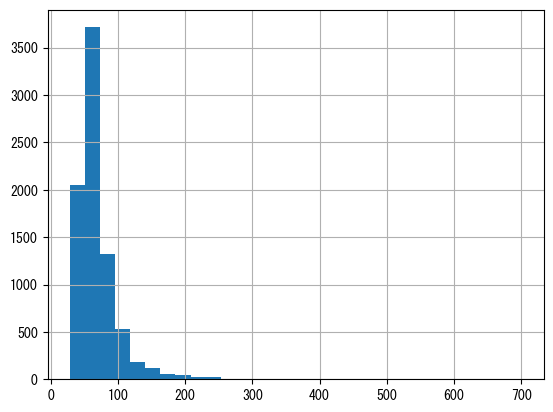

In [ ]:
# sequenceごとの長さ分布確認
seq_lengths = train.groupby("sequence_id").size()

print(seq_lengths.describe())
seq_lengths.hist(bins=30)


count    8100.000000
mean       31.380123
std         3.584732
min         3.000000
25%        30.000000
50%        31.000000
75%        32.000000
max        71.000000
dtype: float64


<Axes: >

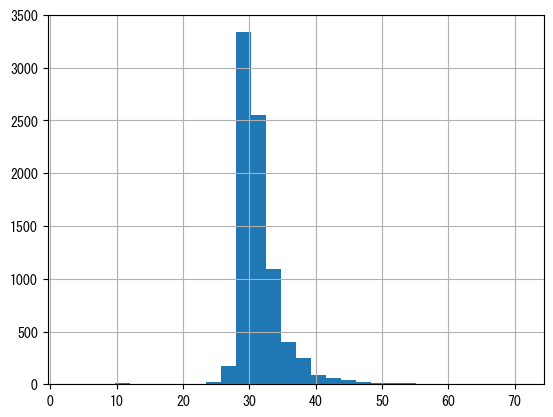

In [ ]:
# フェーズごとの長さ分布確認
seq_lengths = train[train['phase'] == 'Gesture'].groupby("sequence_id").size()

print(seq_lengths.describe())
seq_lengths.hist(bins=30)


In [78]:
from typing import Optional

def visualize_gesture_ratio_transition(sequence_id: str, df: pd.DataFrame, 
                                     window_size: int = 32, stride: int = 8,
                                     feature_config: Optional[IMUFeatureConfig] = None,
                                     figsize: tuple = (15, 8)):
    """
    指定したシーケンスIDのGesture割合推移を可視化
    
    Args:
        sequence_id: 可視化対象のシーケンスID
        df: train.csvを読み込んだDataFrame
        window_size: ウィンドウサイズ
        stride: ストライド
        feature_config: IMU特徴量設定
        figsize: グラフサイズ
    """
    # 指定されたシーケンスのデータを抽出
    seq_data = df[df["sequence_id"] == sequence_id].sort_values("sequence_counter").reset_index(drop=True)
    
    if len(seq_data) == 0:
        print(f"シーケンスID '{sequence_id}' が見つかりません。")
        return
    
    print(f"シーケンス '{sequence_id}' を可視化中...")
    print(f"データ長: {len(seq_data)} points")
    
    
    # ウィンドウごとのGesture割合を計算
    window_centers = []
    gesture_ratios = []
    
    for start in range(0, len(seq_data) - window_size + 1, stride):
        end = start + window_size
        
        # ウィンドウ中心位置
        center = start + window_size // 2
        window_centers.append(center)
        
        # そのウィンドウのGesture割合を計算
        y_win = seq_data["phase"].iloc[start:end].values
        gesture_ratio = np.sum(y_win == "Gesture") / window_size
        gesture_ratios.append(gesture_ratio)
    
    # グラフ作成
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True, height_ratios=[1, 2])
    
    # 上のサブプロット：元のphaseデータ
    phase_numeric = (seq_data["phase"] == "Gesture").astype(int)
    x_axis = seq_data["sequence_counter"].values
    
    # 背景色でphaseを表示
    for i in range(len(seq_data)):
        color = 'lightcoral' if seq_data["phase"].iloc[i] == "Gesture" else 'lightblue'
        ax1.axvspan(x_axis[i], x_axis[i] + 1 if i < len(x_axis) - 1 else x_axis[i] + 1, 
                   color=color, alpha=0.7)
    
    ax1.plot(x_axis, phase_numeric, 'k-', linewidth=2, label='Phase (0=Transition, 1=Gesture)')
    ax1.set_ylabel('Phase')
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Transition', 'Gesture'])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'シーケンス {sequence_id}: Phase と Gesture割合の推移')
    
    # 下のサブプロット：ウィンドウごとのGesture割合
    window_x = [x_axis[center] for center in window_centers]
    
    ax2.plot(window_x, gesture_ratios, 'o-', color='red', linewidth=2, markersize=4,
             label=f'Gesture割合 (window_size={window_size}, stride={stride})')
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50%ライン')
    
    ax2.set_ylabel('Gesture割合')
    ax2.set_xlabel('Sequence Counter')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 統計情報を表示
    stats_text = f"""
    統計情報:
    - 全データ点数: {len(seq_data)}
    - ウィンドウ数: {len(gesture_ratios)}
    - Gesture割合の平均: {np.mean(gesture_ratios):.3f}
    - Gesture割合の標準偏差: {np.std(gesture_ratios):.3f}
    - 元データのGesture率: {np.mean(phase_numeric):.3f}
    """
    
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # 追加の分析情報
    print(f"\n=== 詳細統計 ===")
    print(f"元データのGesture点数: {np.sum(phase_numeric)} / {len(phase_numeric)} ({np.mean(phase_numeric):.1%})")
    print(f"ウィンドウ数: {len(gesture_ratios)}")
    print(f"Gesture割合の分布:")
    print(f"  - 平均: {np.mean(gesture_ratios):.3f}")
    print(f"  - 中央値: {np.median(gesture_ratios):.3f}")
    print(f"  - 最小値: {np.min(gesture_ratios):.3f}")
    print(f"  - 最大値: {np.max(gesture_ratios):.3f}")
    
    # 割合別の分布
    ratio_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ratio_counts = np.histogram(gesture_ratios, bins=ratio_bins)[0]
    print(f"\nGesture割合の分布:")
    for i in range(len(ratio_bins)-1):
        percentage = ratio_counts[i] / len(gesture_ratios) * 100
        print(f"  {ratio_bins[i]:.1f}-{ratio_bins[i+1]:.1f}: {ratio_counts[i]} windows ({percentage:.1f}%)")

シーケンス 'SEQ_000965' を可視化中...
データ長: 46 points


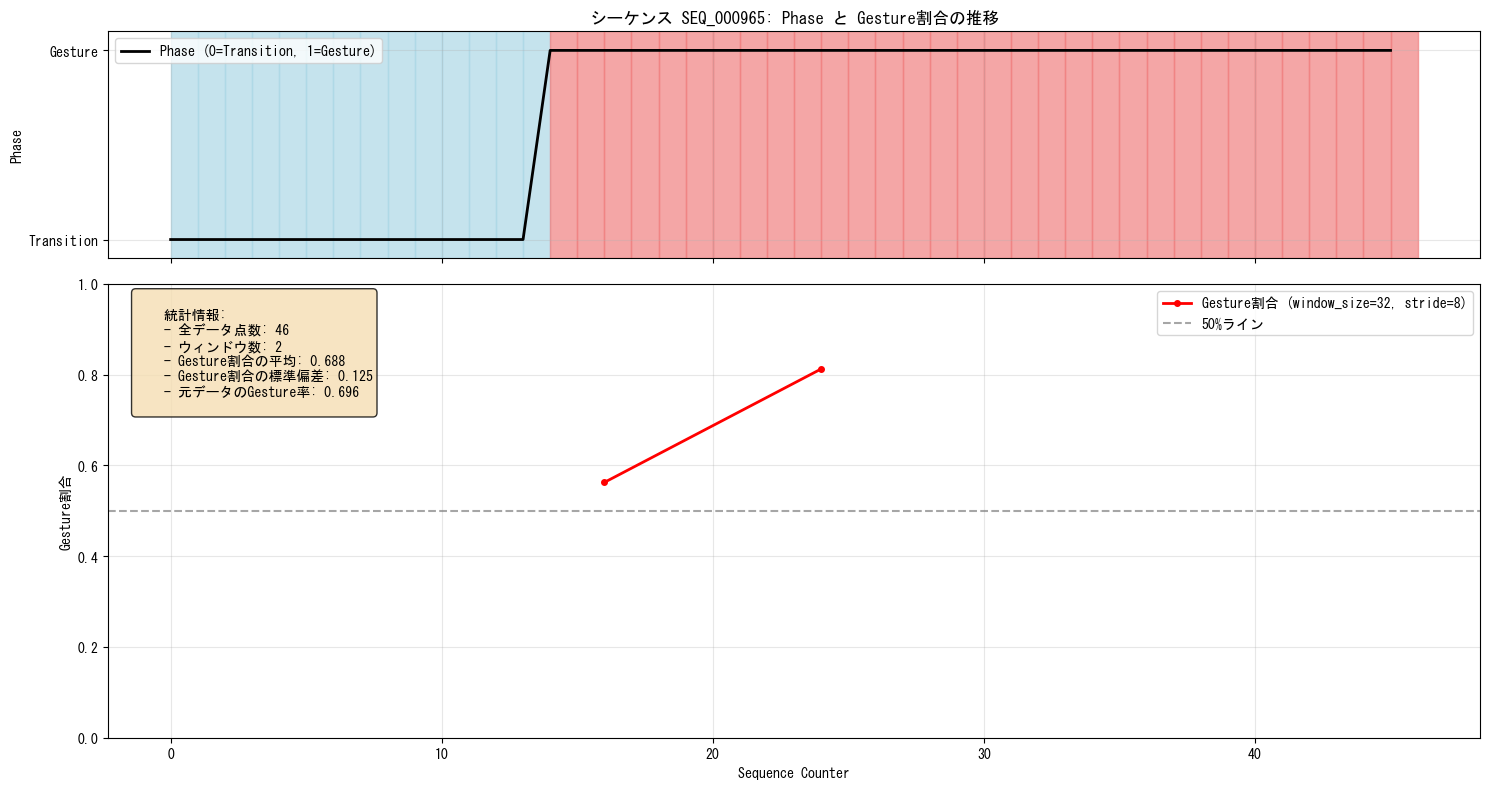


=== 詳細統計 ===
元データのGesture点数: 32 / 46 (69.6%)
ウィンドウ数: 2
Gesture割合の分布:
  - 平均: 0.688
  - 中央値: 0.688
  - 最小値: 0.562
  - 最大値: 0.812

Gesture割合の分布:
  0.0-0.2: 0 windows (0.0%)
  0.2-0.4: 0 windows (0.0%)
  0.4-0.6: 1 windows (50.0%)
  0.6-0.8: 0 windows (0.0%)
  0.8-1.0: 1 windows (50.0%)


In [85]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

# 特定のジェスチャーの時系列データをプロット
target_gesture = "Cheek - pinch skin"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    visualize_gesture_ratio_transition(target_sequences[11], train)

In [20]:
def generate_phase_windows(df, window_size=32, stride=8, 
                          feature_config: Optional[IMUFeatureConfig] = None):
    """
    高度なIMU特徴量を使用してフェーズウィンドウを生成（回帰版）
    
    Args:
        df: train.csvを読み込んだDataFrame
        window_size: 1ウィンドウの長さ（例: 32）
        stride: ウィンドウのスライド幅（例: 8）
        feature_config: IMU特徴量作成の設定
        
    Returns:
        windows: 特徴量ウィンドウの配列 (n_windows, window_size, n_features)
        gesture_ratios: ジェスチャー割合の配列（0.0〜1.0の連続値）
        feature_names: 特徴量名のリスト
    """
    if feature_config is None:
        feature_config = IMUFeatureConfig()
    
    windows = []
    gesture_ratios = []  # ラベルの代わりに割合を保存
    feature_names = None
    
    print(f"ウィンドウ生成開始: window_size={window_size}, stride={stride}")
    
    # シーケンスグループを取得
    sequence_groups = list(df.groupby("sequence_id"))
    
    # tqdmでプログレスバーを表示
    for seq_id, group in tqdm(sequence_groups, desc="シーケンス処理中", unit="seq"):
        try:
            group = group.sort_values("sequence_counter").reset_index(drop=True)
            
            # シーケンス全体でIMU特徴量を作成（一度だけ）
            imu_features_df = create_imu_features(group)
            
            # 特徴量名を初回のみ保存
            if feature_names is None:
                feature_names = list(imu_features_df.columns)
            
            # フェーズ情報
            y_seq = group["phase"].values
            
            # ウィンドウを生成
            for start in range(0, len(group) - window_size + 1, stride):
                end = start + window_size
                
                # 特徴量ウィンドウを抽出
                X_win = imu_features_df.iloc[start:end].values
                y_win = y_seq[start:end]
                
                # NaNチェック
                if np.any(np.isnan(X_win)):
                    X_win = pd.DataFrame(X_win).fillna(method='ffill').fillna(0).values
                
                # Gesture割合を計算（回帰のターゲット）
                gesture_ratio = np.sum(y_win == "Gesture") / window_size
                
                windows.append(X_win)
                gesture_ratios.append(gesture_ratio)  # 割合そのものを保存
                
        except Exception as e:
            print(f"シーケンス {seq_id} の処理でエラー: {e}")
            continue
    
    windows = np.array(windows)
    gesture_ratios = np.array(gesture_ratios)  # 連続値の配列
    
    print(f"ウィンドウ生成完了: {len(windows)} windows, 特徴量次元: {windows.shape}")
    print(f"ジェスチャー割合の分布: 平均={gesture_ratios.mean():.3f}, 標準偏差={gesture_ratios.std():.3f}")
    print(f"最小値={gesture_ratios.min():.3f}, 最大値={gesture_ratios.max():.3f}")
    
    return windows, gesture_ratios, feature_names

## Train model (LSTM)

In [ ]:
def build_lstm_regression_model(input_shape, lstm_units=64, dropout_rate=0.2):
    """
    ジェスチャー割合予測用のLSTMモデル
    
    Args:
        input_shape: (window_size, n_features)
        lstm_units: LSTMユニット数
        dropout_rate: ドロップアウト率
        
    Returns:
        Kerasモデル
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(lstm_units // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # 0-1の範囲で出力（割合）
    ])
    
    # 回帰用の設定
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',  # 平均二乗誤差
        metrics=['mae']  # 平均絶対誤差
    )
    
    return model

# モデルの使用例
X_windows, y_ratios, feature_names = generate_phase_windows(train)

# データを学習用と検証用に分割
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_windows, y_ratios, test_size=0.2, random_state=42
)

# モデル構築と学習
model = build_lstm_regression_model(input_shape=(X_train.shape[1], X_train.shape[2]))
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

ウィンドウ生成開始: window_size=32, stride=8


シーケンス処理中:   0%|          | 18/8101 [00:00<01:35, 84.57seq/s]

特徴量数: 27


シーケンス処理中: 100%|██████████| 8101/8101 [01:27<00:00, 92.10seq/s] 


ウィンドウ生成完了: 43555 windows, 特徴量次元: (43555, 32, 27)
ジェスチャー割合の分布: 平均=0.360, 標準偏差=0.341
最小値=0.000, 最大値=1.000
Epoch 1/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0461 - mae: 0.1499 - val_loss: 0.0213 - val_mae: 0.0801
Epoch 2/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0215 - mae: 0.0851 - val_loss: 0.0165 - val_mae: 0.0714
Epoch 3/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0180 - mae: 0.0740 - val_loss: 0.0160 - val_mae: 0.0664
Epoch 4/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0155 - mae: 0.0667 - val_loss: 0.0161 - val_mae: 0.0607
Epoch 5/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0152 - mae: 0.0650 - val_loss: 0.0132 - val_mae: 0.0555
Epoch 6/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0138 - mae: 0.0606 - val_loss: 0.0120 - val_mae: 0.0546
Epoch 7/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0123 - mae: 0.0565 - val_loss: 0.0123 - val_mae: 0.0507
Epoch 8/50
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model.save('models/v10/gesture_ratio_regression.keras')

## Confirm prediction

In [21]:
model = load_model('model/gesture_ratio_regression.keras')

In [66]:
def predict_gesture_ratio(model, input_df, window_size=32, stride=8, batch_size=64, verbose=True):
    """
    回帰LSTMモデルを使ってgesture_ratioを予測
    
    Parameters:
    -----------
    model : Keras Model
        ロードされた回帰モデル
    input_df : pd.DataFrame
        入力データ
    window_size : int
        ウィンドウサイズ
    stride : int
        ストライド
    batch_size : int
        予測時のバッチサイズ
    verbose : bool
        統計情報の表示を制御するフラグ（デフォルト：True）
        
    Returns:
    --------
    predictions_df : pd.DataFrame
        予測結果（sequence_id, window_start, window_end, predicted_gesture_ratio含む）
    """
    if verbose:
        print("=== gesture_ratio予測開始 ===")
    
    all_predictions = []
    
    # sequence_idごとに処理
    progress_desc = "Sequence予測中" if verbose else None
    for seq_id, group in tqdm(input_df.groupby("sequence_id"), desc=progress_desc, disable=not verbose):
        group = group.sort_values("sequence_counter").reset_index(drop=True)
        
        # ウィンドウが作成できない場合は予測値を0.1で埋める
        if len(group) < window_size:
            if verbose:
                print(f"Sequence {seq_id}: データ長不足 ({len(group)} < {window_size}) -> 予測値0.1で埋める")
            
            # データ不足の場合の処理
            result = {
                'sequence_id': seq_id,
                'window_start': 0,
                'window_end': len(group),
                'start_counter': group.iloc[0]['sequence_counter'] if len(group) > 0 else 0,
                'end_counter': group.iloc[-1]['sequence_counter'] if len(group) > 0 else 0,
                'center_counter': group.iloc[len(group)//2]['sequence_counter'] if len(group) > 0 else 0,
                'predicted_gesture_ratio': 0.1,
                'predicted_gesture_ratio_percent': 10.0
            }
            all_predictions.append(result)
            continue

        # create_imu_features関数で高度な特徴量を作成
        try:
            imu_features_df = create_imu_features(group)
            
            # 特徴量データを取得
            X_seq = imu_features_df.values
            
        except Exception as e:
            if verbose:
                print(f"Sequence {seq_id}: 特徴量作成エラー = {e} -> 予測値0.1で埋める")
            
            # 特徴量作成エラーの場合も0.1で埋める
            result = {
                'sequence_id': seq_id,
                'window_start': 0,
                'window_end': len(group),
                'start_counter': group.iloc[0]['sequence_counter'],
                'end_counter': group.iloc[-1]['sequence_counter'],
                'center_counter': group.iloc[len(group)//2]['sequence_counter'],
                'predicted_gesture_ratio': 0.1,
                'predicted_gesture_ratio_percent': 10.0
            }
            all_predictions.append(result)
            continue
            
        # ウィンドウデータ作成
        windows = []
        window_info = []
        
        for start in range(0, len(group) - window_size + 1, stride):
            end = start + window_size
            X_win = X_seq[start:end]
            
            # NaNチェック
            if np.any(np.isnan(X_win)):
                X_win = pd.DataFrame(X_win).fillna(method='ffill').fillna(0).values
            
            windows.append(X_win)
            window_info.append({
                'sequence_id': seq_id,
                'window_start': start,
                'window_end': end,
                'start_counter': group.iloc[start]['sequence_counter'],
                'end_counter': group.iloc[end-1]['sequence_counter'],
                'center_counter': group.iloc[start + window_size // 2]['sequence_counter']
            })
        
        if not windows:
            # ウィンドウが作成できない場合も0.1で埋める
            if verbose:
                print(f"Sequence {seq_id}: ウィンドウ作成不可 -> 予測値0.1で埋める")
            result = {
                'sequence_id': seq_id,
                'window_start': 0,
                'window_end': len(group),
                'start_counter': group.iloc[0]['sequence_counter'],
                'end_counter': group.iloc[-1]['sequence_counter'],
                'center_counter': group.iloc[len(group)//2]['sequence_counter'],
                'predicted_gesture_ratio': 0.1,
                'predicted_gesture_ratio_percent': 10.0
            }
            all_predictions.append(result)
            continue
            
        # バッチ予測
        windows_array = np.array(windows)
        
        # バッチごとに予測
        for i in range(0, len(windows_array), batch_size):
            batch = windows_array[i:i+batch_size]
            
            # 回帰予測（0-1の連続値）
            predictions = model.predict(batch, verbose=0)
            predictions = predictions.flatten()  # (batch_size, 1) -> (batch_size,)
            
            # 結果を保存
            for j, pred_ratio in enumerate(predictions):
                window_idx = i + j
                
                result = window_info[window_idx].copy()
                result.update({
                    'predicted_gesture_ratio': float(pred_ratio),
                    'predicted_gesture_ratio_percent': float(pred_ratio * 100)  # パーセント表示用
                })
                all_predictions.append(result)
    
    # DataFrame化
    predictions_df = pd.DataFrame(all_predictions)
    
    if verbose:
        print(f"✓ 予測完了")
        print(f"  - 処理シーケンス数: {predictions_df['sequence_id'].nunique()}")
        print(f"  - 予測ウィンドウ数: {len(predictions_df)}")
        
        if len(predictions_df) > 0:
            # 0.1で埋められた予測の数をカウント
            filled_predictions = (predictions_df['predicted_gesture_ratio'] == 0.1).sum()
            actual_predictions = len(predictions_df) - filled_predictions
            
            print(f"  - 実際の予測: {actual_predictions}")
            print(f"  - 0.1で埋めた予測: {filled_predictions}")
            
            if actual_predictions > 0:
                # 実際の予測のみの統計
                actual_ratios = predictions_df[predictions_df['predicted_gesture_ratio'] != 0.1]['predicted_gesture_ratio']
                print(f"  - gesture_ratio統計（実際の予測のみ）:")
                ratio_stats = actual_ratios.describe()
                print(f"    平均: {ratio_stats['mean']:.3f}")
                print(f"    中央値: {ratio_stats['50%']:.3f}")
                print(f"    最小値: {ratio_stats['min']:.3f}")
                print(f"    最大値: {ratio_stats['max']:.3f}")
                print(f"    標準偏差: {ratio_stats['std']:.3f}")
                
                # 割合別の分布
                high_gesture_ratio = (actual_ratios >= 0.5).sum()
                print(f"    高Gesture率(≥50%): {high_gesture_ratio} ({high_gesture_ratio/len(actual_ratios)*100:.1f}%)")
    
    return predictions_df


def assign_gesture_ratio_to_rows(input_df, predictions_df, window_size=32, stride=8, verbose=True):
    """
    ウィンドウ予測結果（gesture_ratio）を各行に割り当て
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        元の入力データ
    predictions_df : pd.DataFrame  
        ウィンドウ予測結果
    window_size : int
        ウィンドウサイズ
    stride : int
        ストライド
    verbose : bool
        統計情報の表示を制御するフラグ（デフォルト：True）
        
    Returns:
    --------
    data_with_predictions : pd.DataFrame
        予測結果が追加された元データ
    """
    if verbose:
        print("=== 予測結果を元データに割り当て ===")
    
    data_with_pred = input_df.copy()
    data_with_pred['predicted_gesture_ratio'] = np.nan
    data_with_pred['prediction_count'] = 0  # 何個のウィンドウで予測されたか
    
    # sequence_idごとに処理
    progress_desc = "行割り当て中" if verbose else None
    for seq_id in tqdm(data_with_pred['sequence_id'].unique(), desc=progress_desc, disable=not verbose):
        seq_mask = data_with_pred['sequence_id'] == seq_id
        seq_data = data_with_pred[seq_mask].sort_values('sequence_counter').reset_index()
        
        # このsequenceの予測結果
        seq_predictions = predictions_df[predictions_df['sequence_id'] == seq_id]
        
        if seq_predictions.empty:
            # 予測結果が無い場合は全て0.1で埋める
            if verbose:
                print(f"Sequence {seq_id}: 予測結果無し -> 全行を0.1で埋める")
            for idx, row in seq_data.iterrows():
                original_idx = row['index']
                data_with_pred.loc[original_idx, 'predicted_gesture_ratio'] = 0.1
                data_with_pred.loc[original_idx, 'prediction_count'] = 0
            continue
            
        # 各行に対してウィンドウからの予測を集約
        for idx, row in seq_data.iterrows():
            counter = row['sequence_counter']
            
            # この行を含むウィンドウを検索
            relevant_predictions = []
            weights = []
            
            for _, pred_row in seq_predictions.iterrows():
                window_start = pred_row['start_counter']
                window_end = pred_row['end_counter']
                window_center = pred_row['center_counter']
                
                # この行がウィンドウに含まれるか
                if window_start <= counter <= window_end:
                    # ウィンドウ中心からの距離に基づく重み（修正版）
                    distance = abs(counter - window_center)
                    max_distance = window_size // 2
                    
                    # 重みが0にならないように調整（最小重み0.1を保証）
                    if max_distance > 0:
                        weight = max(0.1, 1 - distance / max_distance)
                    else:
                        weight = 1.0  # max_distanceが0の場合（window_size=1など）
                    
                    relevant_predictions.append(pred_row['predicted_gesture_ratio'])
                    weights.append(weight)
            
            original_idx = row['index']
            
            if relevant_predictions:
                # 重みの合計チェック
                weight_sum = sum(weights)
                if weight_sum > 0:
                    # 重み付き平均を計算
                    weighted_ratio = np.average(relevant_predictions, weights=weights)
                else:
                    # 重みが全て0の場合は単純平均
                    weighted_ratio = np.mean(relevant_predictions)
                
                # 元のデータフレームに割り当て
                data_with_pred.loc[original_idx, 'predicted_gesture_ratio'] = weighted_ratio
                data_with_pred.loc[original_idx, 'prediction_count'] = len(relevant_predictions)
            else:
                # 該当するウィンドウが見つからない場合は0.1で埋める
                data_with_pred.loc[original_idx, 'predicted_gesture_ratio'] = 0.1
                data_with_pred.loc[original_idx, 'prediction_count'] = 0
    
    # 最終的なNullチェックと埋め処理
    null_mask = data_with_pred['predicted_gesture_ratio'].isna()
    null_count = null_mask.sum()
    
    if null_count > 0:
        if verbose:
            print(f"残りのNull値 {null_count} 行を0.1で埋める")
        data_with_pred.loc[null_mask, 'predicted_gesture_ratio'] = 0.1
        data_with_pred.loc[null_mask, 'prediction_count'] = 0
    
    if verbose:
        # 統計情報
        predicted_rows = data_with_pred['predicted_gesture_ratio'].notna().sum()
        filled_with_default = (data_with_pred['predicted_gesture_ratio'] == 0.1).sum()
        actual_predictions = predicted_rows - filled_with_default
        total_rows = len(data_with_pred)
        
        print(f"✓ 割り当て完了")
        print(f"  - 総行数: {total_rows}")
        print(f"  - 予測有効行数: {predicted_rows} ({predicted_rows/total_rows*100:.1f}%)")
        print(f"  - 実際の予測行数: {actual_predictions} ({actual_predictions/total_rows*100:.1f}%)")
        print(f"  - 0.1で埋めた行数: {filled_with_default} ({filled_with_default/total_rows*100:.1f}%)")
        
        if actual_predictions > 0:
            # 実際の予測のみの統計（0.1で埋めたものを除く）
            actual_ratios = data_with_pred[data_with_pred['predicted_gesture_ratio'] != 0.1]['predicted_gesture_ratio']
            print(f"  - 実際の予測の統計:")
            print(f"    平均gesture_ratio: {actual_ratios.mean():.3f}")
            print(f"    中央値gesture_ratio: {actual_ratios.median():.3f}")
            print(f"    標準偏差: {actual_ratios.std():.3f}")
        
        # 全体の統計
        all_ratios = data_with_pred['predicted_gesture_ratio']
        print(f"  - 全体の統計（0.1埋めを含む）:")
        print(f"    平均gesture_ratio: {all_ratios.mean():.3f}")
        print(f"    中央値gesture_ratio: {all_ratios.median():.3f}")
        print(f"    標準偏差: {all_ratios.std():.3f}")
    
    return data_with_pred

In [115]:
predictions_df = predict_gesture_ratio(
    model=model,
    input_df=train,
    window_size=32,
    stride=8
)

=== gesture_ratio予測開始 ===


Sequence予測中:  14%|█▍        | 1144/8101 [01:19<07:05, 16.34it/s]

Sequence SEQ_009199: データ長不足 (29 < 32) -> 予測値0.1で埋める


Sequence予測中: 100%|██████████| 8101/8101 [09:44<00:00, 13.87it/s]


✓ 予測完了
  - 処理シーケンス数: 8101
  - 予測ウィンドウ数: 43556
  - 実際の予測: 43555
  - 0.1で埋めた予測: 1
  - gesture_ratio統計（実際の予測のみ）:
    平均: 0.354
    中央値: 0.333
    最小値: 0.000
    最大値: 0.996
    標準偏差: 0.322
    高Gesture率(≥50%): 16082 (36.9%)


In [ ]:
train_with_gesture_ratio = assign_gesture_ratio_to_rows(
    input_df=train,
    predictions_df=predictions_df,
    window_size=32,
    stride=8
)

=== 予測結果を元データに割り当て ===


行割り当て中: 100%|██████████| 8101/8101 [06:20<00:00, 21.28it/s]


✓ 割り当て完了
  - 総行数: 571253
  - 予測有効行数: 571253 (100.0%)
  - 実際の予測行数: 542846 (95.0%)
  - 0.1で埋めた行数: 28407 (5.0%)
  - 実際の予測の統計:
    平均gesture_ratio: 0.402
    中央値gesture_ratio: 0.416
    標準偏差: 0.316
  - 全体の統計（0.1埋めを含む）:
    平均gesture_ratio: 0.387
    中央値gesture_ratio: 0.385
    標準偏差: 0.315


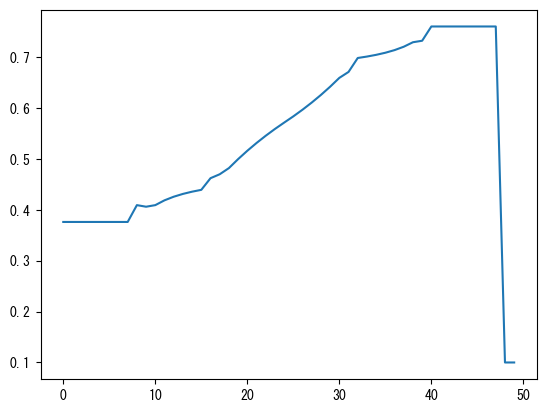

In [ ]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

# 特定のジェスチャーの時系列データをプロット
target_gesture = "Eyebrow - pull hair"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    x = train_with_gesture_ratio[train_with_gesture_ratio['sequence_id'] == target_sequences[100]]['sequence_counter']
    y = train_with_gesture_ratio[train_with_gesture_ratio['sequence_id'] == target_sequences[100]]['predicted_gesture_ratio']
    plt.plot(x, y)
    plt.show()

# Training gesture prediction model

## Predict gesture phase

In [39]:
gesture_phase_prediction_model = load_model('model/gesture_ratio_regression.keras')

In [40]:
gesture_phase_pred_df = predict_gesture_ratio(
    model=gesture_phase_prediction_model,
    input_df=train_balanced,
    window_size=32,
    stride=8
)

=== gesture_ratio予測開始 ===


Sequence予測中: 100%|██████████| 2700/2700 [02:51<00:00, 15.75it/s]

✓ 予測完了
  - 処理シーケンス数: 2700
  - 予測ウィンドウ数: 15240
  - 実際の予測: 15240
  - 0.1で埋めた予測: 0
  - gesture_ratio統計（実際の予測のみ）:
    平均: 0.201
    中央値: 0.003
    最小値: 0.000
    最大値: 0.994
    標準偏差: 0.311
    高Gesture率(≥50%): 3207 (21.0%)


In [41]:
train_with_gesture_ratio = assign_gesture_ratio_to_rows(
    input_df=train_balanced,
    predictions_df=gesture_phase_pred_df,
    window_size=32,
    stride=8
)

=== 予測結果を元データに割り当て ===


行割り当て中: 100%|██████████| 2700/2700 [01:36<00:00, 27.99it/s]


✓ 割り当て完了
  - 総行数: 196288
  - 予測有効行数: 196288 (100.0%)
  - 実際の予測行数: 186720 (95.1%)
  - 0.1で埋めた行数: 9568 (4.9%)
  - 実際の予測の統計:
    平均gesture_ratio: 0.237
    中央値gesture_ratio: 0.024
    標準偏差: 0.315
  - 全体の統計（0.1埋めを含む）:
    平均gesture_ratio: 0.230
    中央値gesture_ratio: 0.040
    標準偏差: 0.309


## Create Features

In [42]:
DEMOGRAPHIC_COLUMNS = ['age', 'sex', 'height_cm', 'handedness']
SEX_MAPPING = {'F': 0, 'M': 1}
HANDEDNESS_MAPPING = {'L': 0, 'R': 1, 'A': 2}


def _process_demographic_data(subject_id: str, demographics_dataframe: pd.DataFrame) -> dict:
    """
    被験者のデモグラフィックデータを処理する
    
    Args:
        subject_id: 被験者ID
        demographics_dataframe: デモグラフィックデータのDataFrame
    
    Returns:
        dict: 処理されたデモグラフィック特徴量
    """
    demographic_features = {}
    
    try:
        demographic_row = demographics_dataframe[demographics_dataframe['subject'] == subject_id]
        
        if demographic_row.empty:
            # デモグラフィックデータが見つからない場合はNaNで埋める
            for column in DEMOGRAPHIC_COLUMNS:
                demographic_features[column] = np.nan
        else:
            demographic_data = demographic_row.iloc[0]
            for column in DEMOGRAPHIC_COLUMNS:
                demographic_features[column] = demographic_data.get(column, np.nan)
                
    except Exception as e:
        print(f"デモグラフィックデータ処理でエラーが発生しました（被験者: {subject_id}）: {e}")
        # エラーの場合もNaNで埋める
        for column in DEMOGRAPHIC_COLUMNS:
            demographic_features[column] = np.nan
    
    return demographic_features


def _encode_categorical_features(features_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    カテゴリカル特徴量をエンコードする
    
    Args:
        features_dataframe: 特徴量DataFrame
    
    Returns:
        pd.DataFrame: エンコード後のDataFrame
    """
    encoded_dataframe = features_dataframe.copy()
    
    # 性別のエンコード
    if 'sex' in encoded_dataframe.columns:
        encoded_dataframe['sex'] = encoded_dataframe['sex'].map(SEX_MAPPING)
        
    # 利き手のエンコード
    if 'handedness' in encoded_dataframe.columns:
        encoded_dataframe['handedness'] = encoded_dataframe['handedness'].map(HANDEDNESS_MAPPING)
    
    return encoded_dataframe

In [50]:
def process_sensor_data(df: pd.DataFrame, use_extra: bool = False) -> Dict[str, float]:
    """
    Extracts an enhanced set of features from sensor data for gesture prediction.
    """
    feats = {}

    # IMU
    imu_features = extract_imu_features(df)
    feats.update(imu_features)

    # Extra Sensor Features (Thermal & ToF)
    if use_extra:
        thm_cols = [c for c in df.columns if 'thm' in c]
        tof_cols = [c for c in df.columns if 'tof' in c]
        
        # Thermal
        if thm_cols:
            thm_features = extract_thermal_features(df)
            feats.update(thm_features)

        # ToF
        if tof_cols:
            tof_features = extract_tof_features(df, use_lstm=True)
            feats.update(tof_features)

    return feats


def find_best_gesture_window(sequence_data: pd.DataFrame, window_size: int = 32) -> pd.DataFrame:
    """
    スライディングウィンドウを使って最適なジェスチャー区間を見つける
    
    Args:
        sequence_data: 時系列順にソートされたシーケンスデータ
        window_size: ウィンドウサイズ（デフォルト32）
    
    Returns:
        pd.DataFrame: 最適なジェスチャー区間のデータ
    """
    # predicted_gesture_ratioが存在しない場合は例外を発生させる
    if 'predicted_gesture_ratio' not in sequence_data.columns:
        raise ValueError("predicted_gesture_ratioが存在しません")

    # データがウィンドウサイズ未満の場合は全てのデータを返す
    if len(sequence_data) < window_size:
        return sequence_data
    
    # スライディングウィンドウで最適な区間を探索
    best_window_start = 0
    best_avg_gesture_ratio = -1
    
    # 可能な全てのウィンドウ位置をチェック
    total_windows = len(sequence_data) - window_size + 1
    for start_idx in range(total_windows):
        end_idx = start_idx + window_size
        current_window = sequence_data.iloc[start_idx:end_idx]
        avg_gesture_ratio = current_window['predicted_gesture_ratio'].mean()
        
        # より良いウィンドウが見つかった場合は更新
        if avg_gesture_ratio > best_avg_gesture_ratio:
            best_avg_gesture_ratio = avg_gesture_ratio
            best_window_start = start_idx
    
    # 最適なウィンドウを抽出して返す
    optimal_window = sequence_data.iloc[best_window_start:best_window_start + window_size]
    return optimal_window


def build_features(data: pd.DataFrame, demographics: pd.DataFrame, use_extra: bool) -> tuple[pd.DataFrame, list]:
    """
    データから特徴量マトリックスを構築し、クロスバリデーション用のグループ情報を返す
    
    Args:
        data: メインのセンサーデータ
        demographics: デモグラフィックデータ
        use_extra: 追加センサーを使用するかどうか
    
    Returns:
        tuple: (特徴量DataFrame, 被験者グループのリスト)
    """
    feature_list = []
    subject_groups = []
        
    # シーケンスIDごとに特徴量を抽出
    for sequence_id, sequence_data in tqdm(list(data.groupby('sequence_id')), desc="特徴量抽出中"):
        try:
            # 被験者IDを取得
            subject_id = sequence_data['subject'].iloc[0]
            subject_groups.append(subject_id)

            # 時系列順にソートして最適なジェスチャー区間を抽出
            sequence_sorted_by_time = sequence_data.sort_values('sequence_counter', ascending=True)
            optimal_gesture_phase = find_best_gesture_window(sequence_sorted_by_time, window_size=32)
            
            # 1. センサー特徴量を抽出
            sensor_features = process_sensor_data(optimal_gesture_phase, use_extra=use_extra)
            
            # 2. デモグラフィック特徴量を抽出
            demographic_features = _process_demographic_data(subject_id, demographics)
            
            # 3. 全ての特徴量を合体
            all_features = {**sensor_features, **demographic_features}
            
            # 4. シーケンスIDを追加
            all_features['sequence_id'] = sequence_id
            
            feature_list.append(all_features)
            
        except Exception as e:
            print(f"シーケンス {sequence_id} の処理でエラーが発生しました: {e}")
            continue
    
    # DataFrame化とインデックス設定
    features_dataframe = pd.DataFrame(feature_list).set_index('sequence_id')
    
    # カテゴリカル特徴量のエンコード
    features_dataframe = _encode_categorical_features(features_dataframe)
        
    return features_dataframe, subject_groups

In [77]:
def create_dual_feature_datasets(train, train_d) -> tuple[pd.DataFrame, pd.Series, list, pd.DataFrame, pd.Series, list]:
    """
    IMU-onlyとFull-sensorの2つの特徴量セットを作成
    """
    print("=== 特徴量セット作成 ===")
    
    # IMU-only用データ作成
    train_imu = train.copy()
    train_imu[thm_cols + tof_cols] = np.nan
    
    # Full-sensor用データ作成（元々full-sensorがあるシーケンスのみ）
    full_sensor_sequences = train[
        ~train['sequence_id'].isin(imu_only_seq_ids)
    ]['sequence_id'].unique()
    
    print(f"IMU-only対象: {len(train_imu['sequence_id'].unique())} sequences")
    print(f"Full-sensor対象: {len(full_sensor_sequences)} sequences")
    
    # 特徴量構築
    print("IMU-only特徴量構築中...")
    X_imu, groups_imu = build_features(
        train_imu, train_d, use_extra=False
    )
    y_imu = train_imu.groupby('sequence_id')['e_gesture'].first().loc[X_imu.index]
    
    print("Full-sensor特徴量構築中...")
    X_full, groups_full = build_features(
        train[train['sequence_id'].isin(full_sensor_sequences)], 
        train_d, use_extra=True
    )
    y_full = train.groupby('sequence_id')['e_gesture'].first().loc[X_full.index]
    
    print(f"\n=== 特徴量セット完成 ===")
    print(f"IMU-only: {X_imu.shape} (samples × features)")
    print(f"Full-sensor: {X_full.shape} (samples × features)")
    
    return (X_imu, y_imu, groups_imu, 
            X_full, y_full, groups_full)

In [ ]:
# 特徴量セット作成
(X_imu_bal, y_imu_bal, groups_imu_bal, 
 X_full_bal, y_full_bal, groups_full_bal) = create_dual_feature_datasets(train_with_gesture_ratio, train_d)

=== 軽量化特徴量セット作成 ===
IMU-only対象: 2700 sequences
Full-sensor対象: 2517 sequences
IMU-only特徴量構築中...
特徴量構築開始: 2700 シーケンス処理中...


特徴量抽出中: 100%|██████████| 2700/2700 [01:05<00:00, 41.24it/s]


特徴量構築完了: 2700 サンプル × 360 特徴量
Full-sensor特徴量構築中...
特徴量構築開始: 2517 シーケンス処理中...


特徴量抽出中: 100%|██████████| 2517/2517 [02:14<00:00, 18.71it/s]


特徴量構築完了: 2517 サンプル × 872 特徴量

=== 特徴量セット完成 ===
IMU-only: (2700, 360) (samples × features)
Full-sensor: (2517, 872) (samples × features)


## CV (GBDT)

In [72]:
def train_cv_and_display_results(model, X, y, groups, model_name, gesture_names, n_folds=3):
    """
    CV混同行列作成 + 最終学習済みモデル返却
    """
    print(f"=== {model_name} CV (n_folds={n_folds}) ===")
    print(f"データサイズ: {X.shape}")
    print(f"被験者グループ数: {len(set(groups))}")
    
    all_true = []
    all_pred = []
    fold_results = []
    
    start_time = time.time()
    
    # ===== CV実行 =====
    for fold, (train_idx, val_idx) in enumerate(GroupKFold(n_splits=n_folds).split(X, y, groups)):
        fold_start = time.time()
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        print(f"Fold {fold+1}: Train={len(X_train)}, Val={len(X_val)}")
        
        # モデル学習
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        
        # 予測
        y_pred = fold_model.predict(X_val)
        
        # 結果保存
        all_true.extend(y_val.values)
        all_pred.extend(y_pred)
        
        # フォールド結果
        fold_acc = (y_pred == y_val).mean()
        fold_f1 = f1_score(y_val, y_pred, average='macro')
        fold_time = time.time() - fold_start
        
        fold_results.append({
            'fold': fold + 1,
            'accuracy': fold_acc,
            'f1_macro': fold_f1,
            'time': fold_time
        })
        
        print(f"  Accuracy: {fold_acc:.3f}, F1-macro: {fold_f1:.3f}, Time: {fold_time:.1f}s")
    
    total_time = time.time() - start_time
    
    # ===== CV結果表示 =====
    overall_accuracy = (np.array(all_true) == np.array(all_pred)).mean()
    overall_f1 = f1_score(all_true, all_pred, average='macro')
    
    print(f"\n=== CV結果 ===")
    print(f"CV精度: {overall_accuracy:.3f}")
    print(f"CV F1-macro: {overall_f1:.3f}")
    print(f"CV実行時間: {total_time:.1f}s")

    # ===== 混同行列作成・表示 =====
    cm = confusion_matrix(all_true, all_pred)

    # 詳細統計の計算
    total_predictions = len(all_true)
    total_correct = np.sum(np.array(all_true) == np.array(all_pred))
    accuracy = total_correct / total_predictions

    # クラス別の統計
    class_stats = []
    for i, gesture in enumerate(gesture_names):
        true_count = np.sum(np.array(all_true) == i)  # 真の件数
        pred_count = np.sum(np.array(all_pred) == i)  # 予測件数  
        correct_count = cm[i, i]  # 正解件数
        
        if true_count > 0:
            recall = correct_count / true_count  # 再現率
        else:
            recall = 0.0
            
        if pred_count > 0:
            precision = correct_count / pred_count  # 適合率
        else:
            precision = 0.0
        
        class_stats.append({
            'gesture': gesture,
            'true_count': true_count,
            'pred_count': pred_count, 
            'correct_count': correct_count,
            'recall': recall,
            'precision': precision
        })

    # 混同行列の表示
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_names, yticklabels=gesture_names)

    # タイトルに全体統計を表示
    plt.title(f'Balanced CV Confusion Matrix - {model_name}\n'
              f'総予測数: {total_predictions:,}件 | 正解数: {total_correct:,}件 | 正解率: {accuracy:.3f}\n'
              f'CV Accuracy: {overall_accuracy:.3f} | CV F1-macro: {overall_f1:.3f}')

    plt.xlabel('Predicted Gesture')
    plt.ylabel('True Gesture')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # クラス別詳細統計の表示
    print(f"\n=== クラス別詳細統計 ===")
    print(f"{'Gesture':<35} {'真の件数':<8} {'予測件数':<8} {'正解件数':<8} {'再現率':<8} {'適合率':<8}")
    print("-" * 85)

    for stat in class_stats:
        print(f"{stat['gesture']:<35} "
              f"{stat['true_count']:<8} "
              f"{stat['pred_count']:<8} "
              f"{stat['correct_count']:<8} "
              f"{stat['recall']:<8.3f} "
              f"{stat['precision']:<8.3f}")

    # 全体サマリー
    print(f"\n=== 全体サマリー ===")
    print(f"総予測数: {total_predictions:,}件")
    print(f"総正解数: {total_correct:,}件") 
    print(f"総誤答数: {total_predictions - total_correct:,}件")
    print(f"正解率: {accuracy:.3f} ({accuracy*100:.1f}%)")

    # 最も混同しやすいペアの表示
    print(f"\n=== 最も混同しやすいジェスチャーペア（上位5位） ===")
    confusion_pairs = []
    for i in range(len(gesture_names)):
        for j in range(len(gesture_names)):
            if i != j and cm[i, j] > 0:  # 対角線以外で値がある
                confusion_pairs.append({
                    'true_gesture': gesture_names[i],
                    'pred_gesture': gesture_names[j], 
                    'count': cm[i, j],
                    'rate': cm[i, j] / np.sum(cm[i, :])  # その真のクラスの中での誤分類率
                })

    # 混同件数でソート
    confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

    print(f"{'真のジェスチャー':<35} {'予測されたジェスチャー':<35} {'誤分類件数':<10} {'誤分類率':<8}")
    print("-" * 95)
    for pair in confusion_pairs[:5]:  # 上位5位
        print(f"{pair['true_gesture']:<35} "
              f"{pair['pred_gesture']:<35} "
              f"{pair['count']:<10} "
              f"{pair['rate']:<8.3f}")
    
    # ===== 最終モデル学習 =====
    print(f"\n=== 最終モデル学習 ===")
    final_model_start = time.time()
    
    # 全データで最終モデルを学習
    final_model = clone(model)
    final_model.fit(X, y)
    
    final_model_time = time.time() - final_model_start
    print(f"最終モデル学習時間: {final_model_time:.1f}s")
    print(f"学習データサイズ: {X.shape}")
    
    # ===== 結果まとめ =====
    results_summary = {
        'cv_accuracy': overall_accuracy,
        'cv_f1_macro': overall_f1,
        'cv_time': total_time,
        'final_model_time': final_model_time,
        'fold_results': fold_results
    }
    
    print(f"\n=== 完了 ===")
    print(f"総実行時間: {total_time + final_model_time:.1f}s")
    
    return cm, all_true, all_pred, final_model, results_summary

In [52]:
def create_lightweight_model_for_analysis(use_gpu=True):
    """
    特徴量重要度分析用の軽量化モデル作成
    """
    base_params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 100,  # 重要度分析用に軽量化
        'learning_rate': 0.1,
        'feature_fraction': 1.0,  # 全特徴量使用
        'bagging_fraction': 0.8,
        'num_leaves': 31,
        'random_state': CFG.seed,
        'verbose': -1,
        'importance_type': 'gain'  # 重要度計算方法指定
    }
    
    if use_gpu:
        base_params.update({
            'device': 'gpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0
        })
    else:
        base_params['device'] = 'cpu'
    
    return LGBMClassifier(**base_params)

In [53]:
analysis_imu_model = create_lightweight_model_for_analysis()
analysis_full_model = create_lightweight_model_for_analysis()

=== IMU-only モデル 学習・分析 ===
=== Lightweight IMU-only LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2700, 360)
被験者グループ数: 81
Fold 1: Train=2162, Val=538
  Accuracy: 0.576, F1-macro: 0.567, Time: 15.9s
Fold 2: Train=2164, Val=536
  Accuracy: 0.558, F1-macro: 0.552, Time: 13.5s
Fold 3: Train=2162, Val=538
  Accuracy: 0.576, F1-macro: 0.570, Time: 13.7s
Fold 4: Train=2162, Val=538
  Accuracy: 0.571, F1-macro: 0.557, Time: 14.7s
Fold 5: Train=2150, Val=550
  Accuracy: 0.569, F1-macro: 0.545, Time: 14.4s

=== CV結果 ===
CV精度: 0.570
CV F1-macro: 0.560
CV実行時間: 72.2s


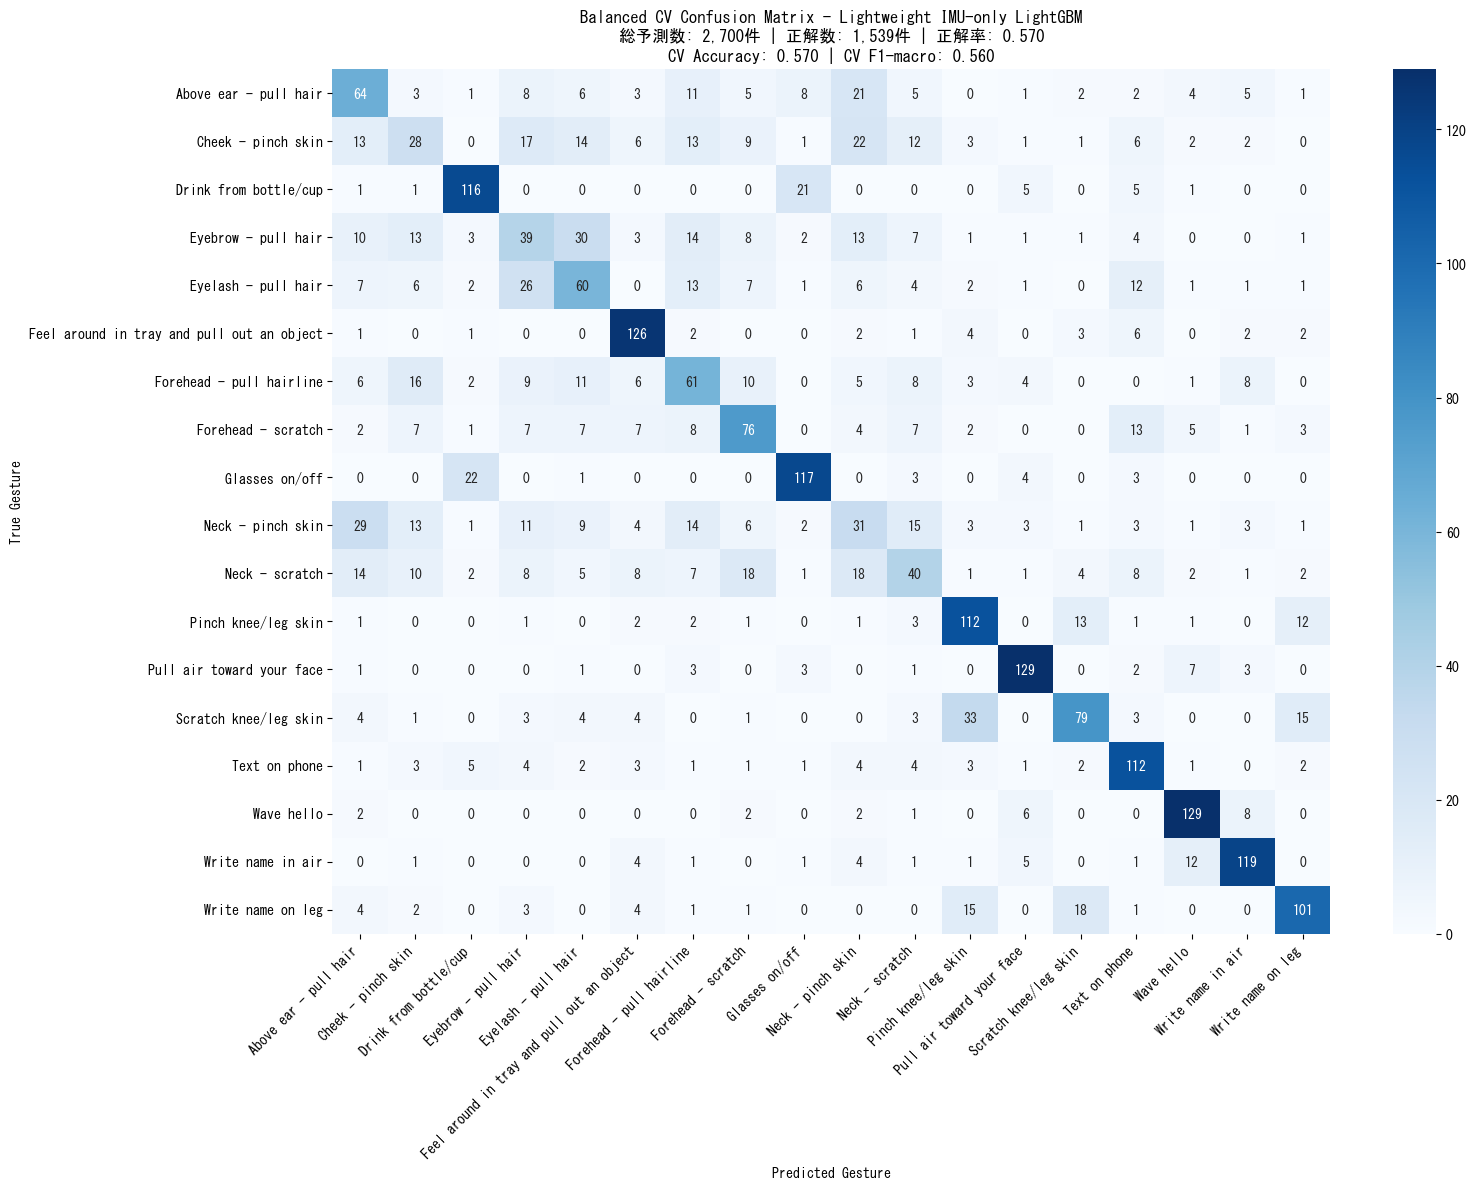


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               150      160      64       0.427    0.400   
Cheek - pinch skin                  150      104      28       0.187    0.269   
Drink from bottle/cup               150      156      116      0.773    0.744   
Eyebrow - pull hair                 150      136      39       0.260    0.287   
Eyelash - pull hair                 150      150      60       0.400    0.400   
Feel around in tray and pull out an object 150      180      126      0.840    0.700   
Forehead - pull hairline            150      151      61       0.407    0.404   
Forehead - scratch                  150      145      76       0.507    0.524   
Glasses on/off                      150      158      117      0.780    0.741   
Neck - pinch skin                   150      133      31       0.207    0.233  

In [ ]:
(cm_imu_bal, y_true_imu_bal, y_pred_imu_bal, 
 trained_imu_model, imu_results) = train_cv_and_display_results(
    analysis_imu_model, X_imu_bal, y_imu_bal, groups_imu_bal, 
    "Lightweight IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

=== Full-sensor モデル 学習・分析 ===
=== Lightweight Full-sensor LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2517, 872)
被験者グループ数: 79
Fold 1: Train=2016, Val=501
  Accuracy: 0.669, F1-macro: 0.654, Time: 23.6s
Fold 2: Train=2016, Val=501
  Accuracy: 0.621, F1-macro: 0.611, Time: 24.1s
Fold 3: Train=2015, Val=502
  Accuracy: 0.641, F1-macro: 0.619, Time: 24.3s
Fold 4: Train=2005, Val=512
  Accuracy: 0.637, F1-macro: 0.633, Time: 24.3s
Fold 5: Train=2016, Val=501
  Accuracy: 0.617, F1-macro: 0.612, Time: 23.9s

=== CV結果 ===
CV精度: 0.637
CV F1-macro: 0.627
CV実行時間: 120.3s


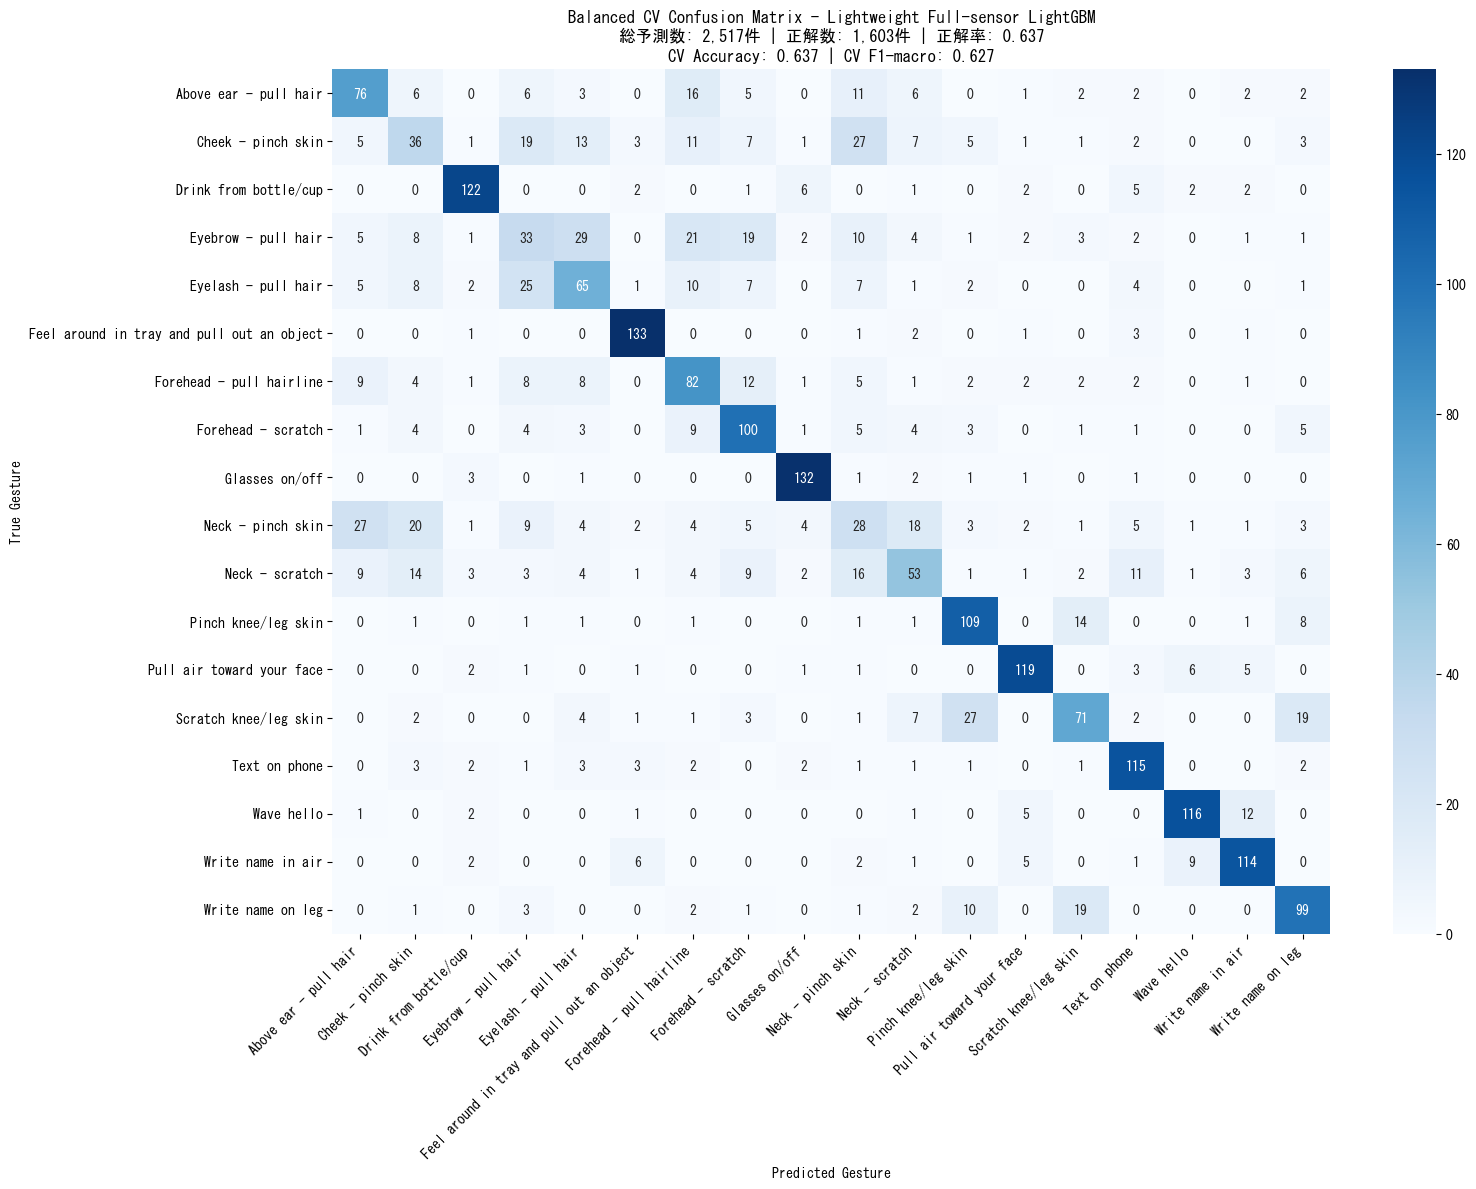


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               138      138      76       0.551    0.551   
Cheek - pinch skin                  142      107      36       0.254    0.336   
Drink from bottle/cup               143      143      122      0.853    0.853   
Eyebrow - pull hair                 142      113      33       0.232    0.292   
Eyelash - pull hair                 138      138      65       0.471    0.471   
Feel around in tray and pull out an object 142      154      133      0.937    0.864   
Forehead - pull hairline            140      163      82       0.586    0.503   
Forehead - scratch                  141      169      100      0.709    0.592   
Glasses on/off                      142      152      132      0.930    0.868   
Neck - pinch skin                   138      118      28       0.203    0.237  

In [ ]:
(cm_full_bal, y_true_full_bal, y_pred_full_bal, 
 trained_full_model, full_results) = train_cv_and_display_results(
    analysis_full_model, X_full_bal, y_full_bal, groups_full_bal, 
    "Lightweight Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

## Train all data

In [87]:
# ジェスチャー比率予測データセット作成
gesture_phase_pred_df_all = predict_gesture_ratio(
    model=gesture_phase_prediction_model,
    input_df=train,
    window_size=32,
    stride=8
)

train_with_gesture_ratio_all = assign_gesture_ratio_to_rows(
    input_df=train,
    predictions_df=gesture_phase_pred_df_all,
    window_size=32,
    stride=8
)

=== gesture_ratio予測開始 ===


Sequence予測中:  14%|█▍        | 1144/8101 [01:13<06:39, 17.43it/s]

Sequence SEQ_009199: データ長不足 (29 < 32) -> 予測値0.1で埋める


Sequence予測中: 100%|██████████| 8101/8101 [08:48<00:00, 15.34it/s]


✓ 予測完了
  - 処理シーケンス数: 8101
  - 予測ウィンドウ数: 43556
  - 実際の予測: 43555
  - 0.1で埋めた予測: 1
  - gesture_ratio統計（実際の予測のみ）:
    平均: 0.202
    中央値: 0.003
    最小値: 0.000
    最大値: 0.994
    標準偏差: 0.310
    高Gesture率(≥50%): 9338 (21.4%)
=== 予測結果を元データに割り当て ===


行割り当て中: 100%|██████████| 8101/8101 [06:18<00:00, 21.43it/s]


✓ 割り当て完了
  - 総行数: 571253
  - 予測有効行数: 571253 (100.0%)
  - 実際の予測行数: 542846 (95.0%)
  - 0.1で埋めた行数: 28407 (5.0%)
  - 実際の予測の統計:
    平均gesture_ratio: 0.237
    中央値gesture_ratio: 0.027
    標準偏差: 0.313
  - 全体の統計（0.1埋めを含む）:
    平均gesture_ratio: 0.230
    中央値gesture_ratio: 0.045
    標準偏差: 0.307


In [88]:
# 特徴量セット作成
(X_imu, y_imu, groups_imu, 
 X_full, y_full, groups_full) = create_dual_feature_datasets(train_with_gesture_ratio_all, train_d)

=== 特徴量セット作成 ===
IMU-only対象: 8101 sequences
Full-sensor対象: 7593 sequences
IMU-only特徴量構築中...


特徴量抽出中: 100%|██████████| 8101/8101 [03:21<00:00, 40.28it/s]


Full-sensor特徴量構築中...


特徴量抽出中: 100%|██████████| 7593/7593 [07:04<00:00, 17.87it/s]



=== 特徴量セット完成 ===
IMU-only: (8101, 360) (samples × features)
Full-sensor: (7593, 872) (samples × features)


In [89]:
analysis_imu_model = create_lightweight_model_for_analysis()
analysis_full_model = create_lightweight_model_for_analysis()

=== IMU-only LightGBM CV (n_folds=5) ===
データサイズ: (8101, 360)
被験者グループ数: 81
Fold 1: Train=6475, Val=1626
  Accuracy: 0.554, F1-macro: 0.593, Time: 17.7s
Fold 2: Train=6487, Val=1614
  Accuracy: 0.602, F1-macro: 0.637, Time: 17.6s
Fold 3: Train=6493, Val=1608
  Accuracy: 0.555, F1-macro: 0.570, Time: 17.6s
Fold 4: Train=6474, Val=1627
  Accuracy: 0.526, F1-macro: 0.549, Time: 17.6s
Fold 5: Train=6475, Val=1626
  Accuracy: 0.558, F1-macro: 0.598, Time: 17.5s

=== CV結果 ===
CV精度: 0.559
CV F1-macro: 0.591
CV実行時間: 88.1s


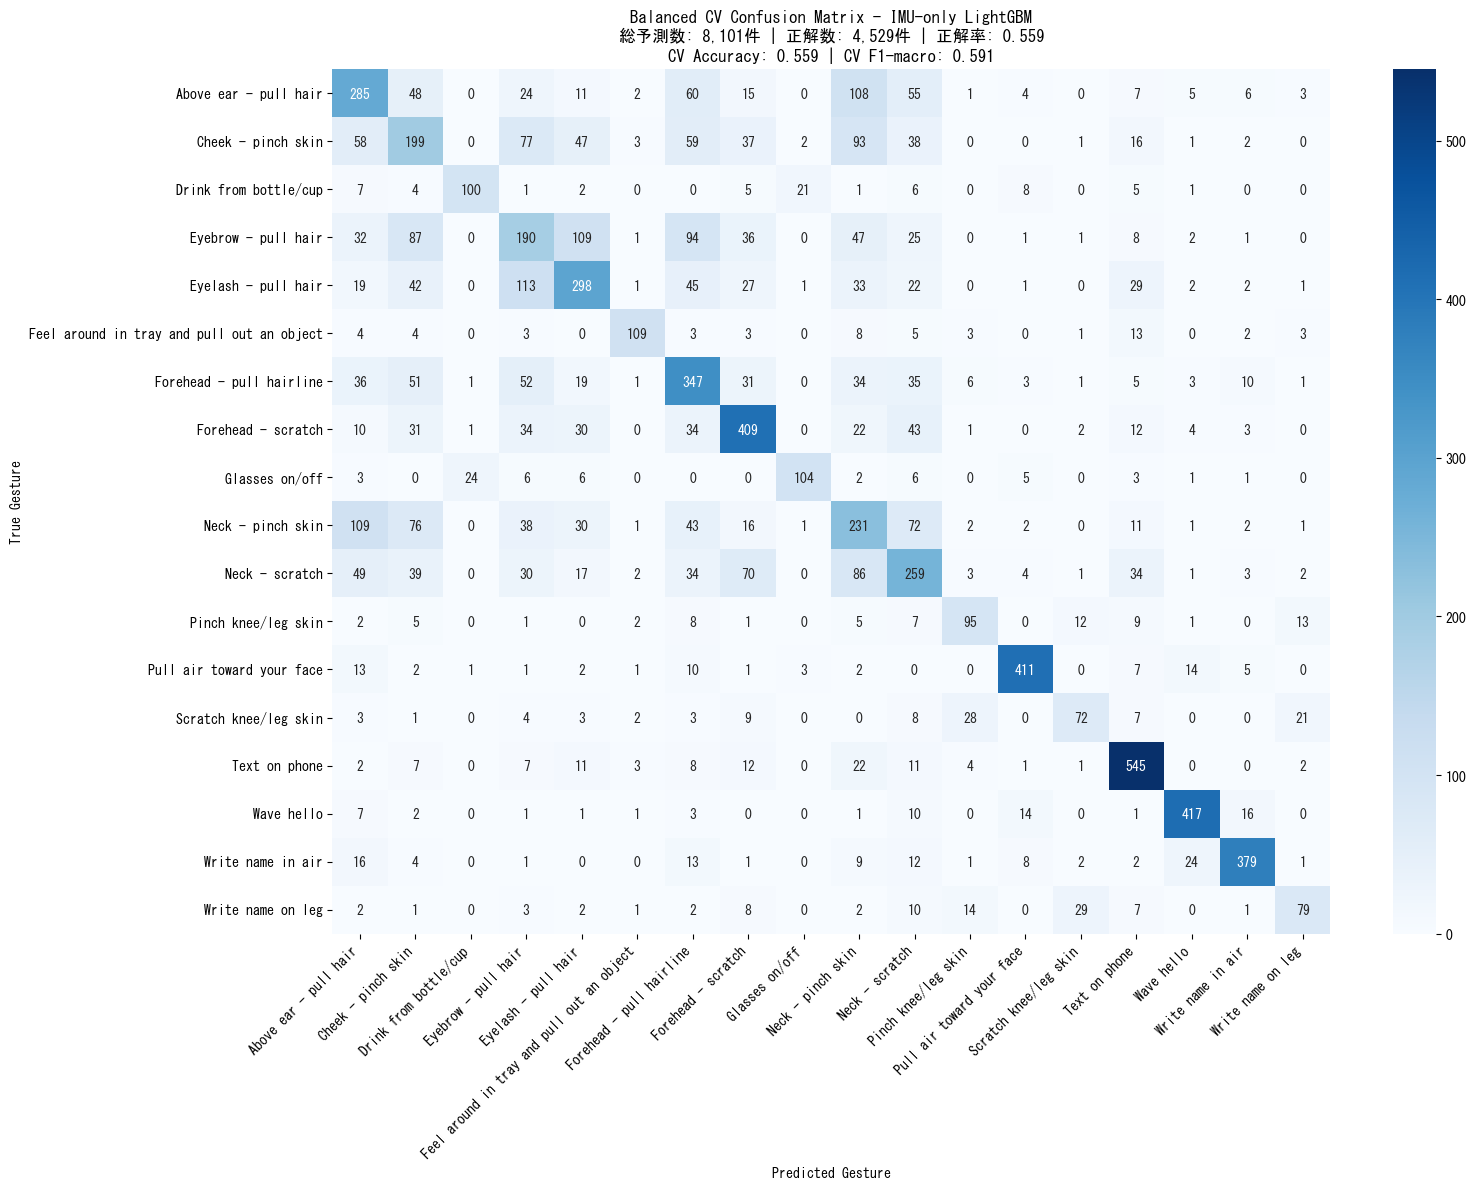


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               634      657      285      0.450    0.434   
Cheek - pinch skin                  633      603      199      0.314    0.330   
Drink from bottle/cup               161      127      100      0.621    0.787   
Eyebrow - pull hair                 634      586      190      0.300    0.324   
Eyelash - pull hair                 636      588      298      0.469    0.507   
Feel around in tray and pull out an object 161      130      109      0.677    0.838   
Forehead - pull hairline            636      766      347      0.546    0.453   
Forehead - scratch                  636      681      409      0.643    0.601   
Glasses on/off                      161      132      104      0.646    0.788   
Neck - pinch skin                   636      706      231      0.363    0.327  

In [90]:
(cm_imu, y_true_imu, y_pred_imu, 
 trained_imu_model, imu_results) = train_cv_and_display_results(
    analysis_imu_model, X_imu, y_imu, groups_imu, 
    "IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

In [91]:
joblib.dump(trained_imu_model, 'models/v10/model_imu.pkl')

['models/v10/model_imu.pkl']

=== Full Sensor LightGBM CV (n_folds=5) ===
データサイズ: (7593, 872)
被験者グループ数: 79
Fold 1: Train=6067, Val=1526
  Accuracy: 0.615, F1-macro: 0.646, Time: 36.2s
Fold 2: Train=6069, Val=1524
  Accuracy: 0.657, F1-macro: 0.688, Time: 36.3s
Fold 3: Train=6082, Val=1511
  Accuracy: 0.578, F1-macro: 0.618, Time: 35.9s
Fold 4: Train=6080, Val=1513
  Accuracy: 0.651, F1-macro: 0.685, Time: 36.6s
Fold 5: Train=6074, Val=1519
  Accuracy: 0.627, F1-macro: 0.662, Time: 36.5s

=== CV結果 ===
CV精度: 0.626
CV F1-macro: 0.660
CV実行時間: 181.5s


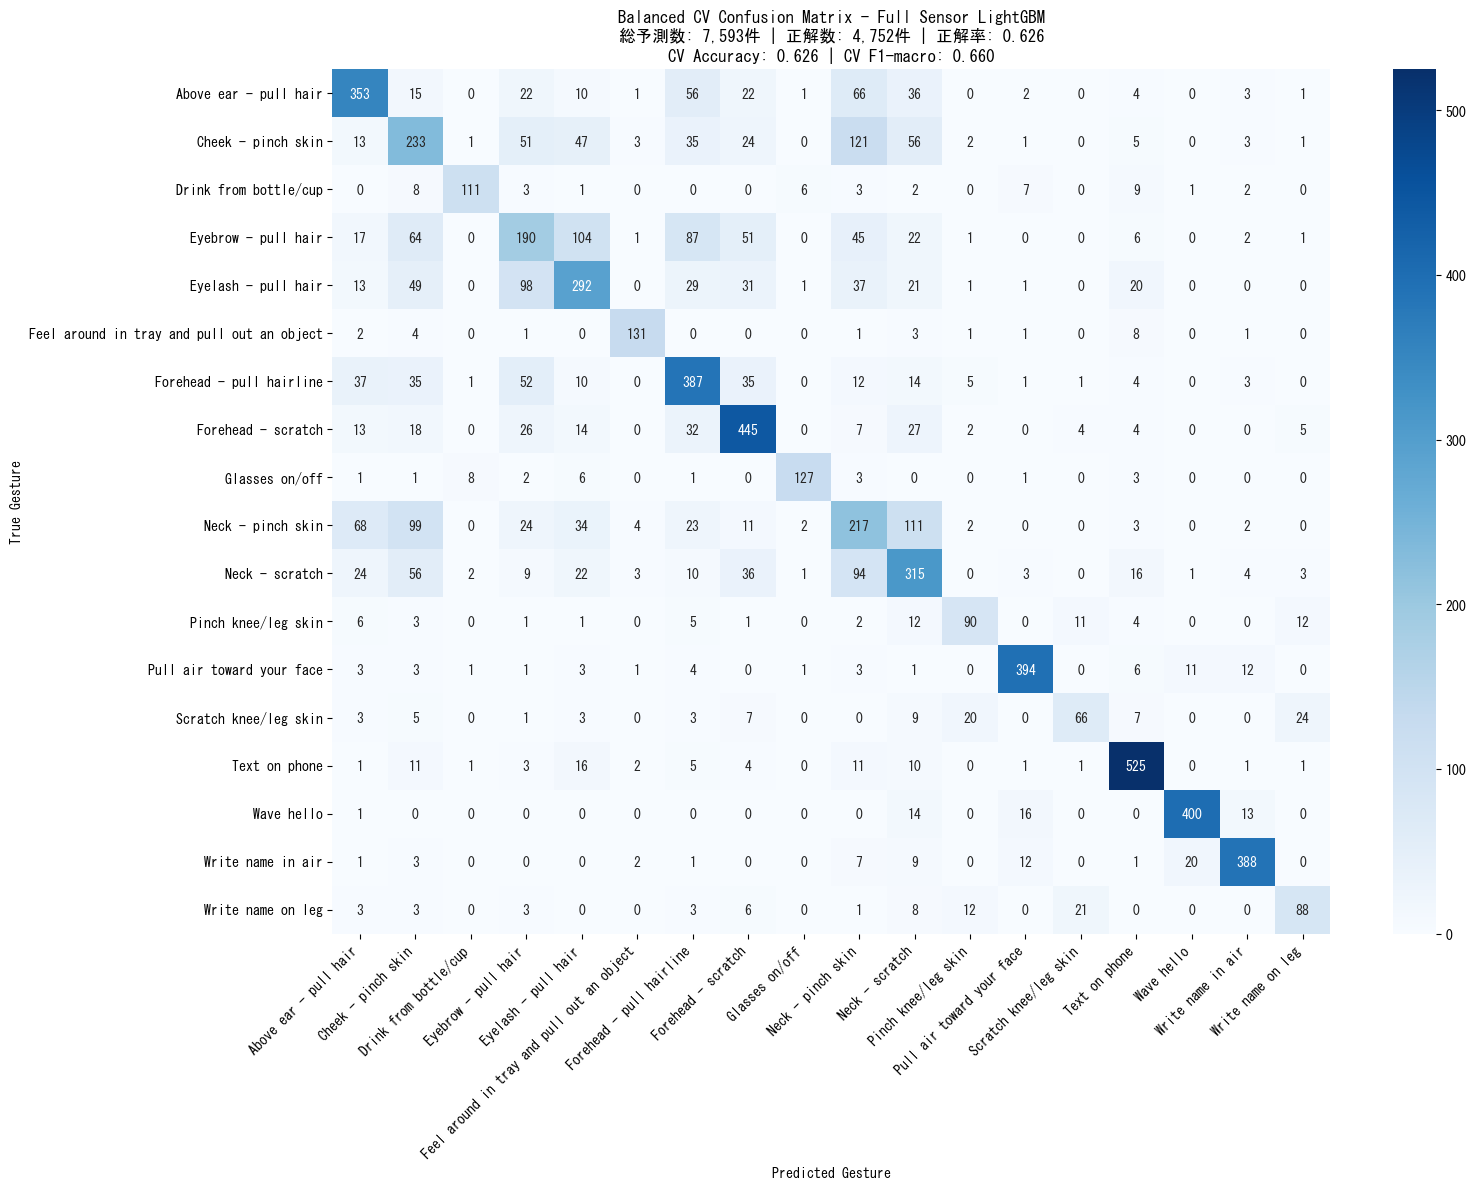


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               592      559      353      0.596    0.631   
Cheek - pinch skin                  596      610      233      0.391    0.382   
Drink from bottle/cup               153      125      111      0.725    0.888   
Eyebrow - pull hair                 591      487      190      0.321    0.390   
Eyelash - pull hair                 593      563      292      0.492    0.519   
Feel around in tray and pull out an object 153      148      131      0.856    0.885   
Forehead - pull hairline            597      681      387      0.648    0.568   
Forehead - scratch                  597      673      445      0.745    0.661   
Glasses on/off                      153      139      127      0.830    0.914   
Neck - pinch skin                   600      630      217      0.362    0.344  

In [92]:
(cm_full, y_true_full, y_pred_full, 
 trained_full_model, full_results) = train_cv_and_display_results(
    analysis_full_model, X_full, y_full, groups_full, 
    "Full Sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

In [93]:
joblib.dump(trained_full_model, 'models/v10/model_full.pkl')

['models/v10/model_full.pkl']

In [94]:
joblib.dump(le_gesture, 'models/v10/le_gesture.pkl')

['models/v10/le_gesture.pkl']

# Submission

In [74]:
MODEL_DIR = "models/v10/"
BASE_PATH = "C:/Users/takah/Documents/02_study/kaggle/cmi-detect-behavior-with-sensor-data/input/"
# MODEL_DIR = "/kaggle/input/cmi-models-v02/v02-02_fix-estimator"
# BASE_PATH = "/kaggle/input/cmi-detect-behavior-with-sensor-data/"

In [57]:
def has_extra_sensors(df: pd.DataFrame) -> bool:
    """Checks if a sequence has valid thermal/ToF sensor data."""
    thm_cols = [c for c in df.columns if 'thm_' in c]
    tof_cols = [c for c in df.columns if 'tof_' in c]
    if not thm_cols or not tof_cols:
        return False
    has_thm = df[thm_cols].notna().any().any()
    has_tof = (df[tof_cols] != -1).any().any()
    return has_thm and has_tof

In [ ]:
class ModelManager:
    """モデル管理クラス"""
    def __init__(self):
        # 最初にすべてのモデルを読み込む
        try:
            self._model_imu = joblib.load(os.path.join(MODEL_DIR, "model_imu.pkl"))
            self._model_extra = joblib.load(os.path.join(MODEL_DIR, "model_full.pkl"))
            self._label_encoder = joblib.load(os.path.join(MODEL_DIR, "le_gesture.pkl"))
            self._gesture_phase_model = load_model(os.path.join(MODEL_DIR,'gesture_ratio_regression.keras'))
            print("すべてのモデルを正常に読み込みました")
        except Exception as e:
            raise ModelLoadError(f"モデル読み込みエラー: {e}")
    
    @property
    def model_imu(self):
        return self._model_imu
    
    @property
    def model_extra(self):
        return self._model_extra
    
    @property
    def label_encoder(self):
        return self._label_encoder
    
    @property
    def gesture_phase_model(self):
        return self._gesture_phase_model


class ModelLoadError(Exception):
    """モデル読み込みエラー"""
    pass


# グローバルインスタンス
_model_manager = ModelManager()


def prepare_features(sequence: pl.DataFrame, demographics: pl.DataFrame) -> tuple[pd.DataFrame, bool]:
    """特徴量の準備とセンサータイプの判定"""
    sequence_pd = sequence.to_pandas()
    demographics_pd = demographics.to_pandas()

    try:
        # gesture_ratio予測
        predictions_df = predict_gesture_ratio(
            model=_model_manager.gesture_phase_model,
            input_df=sequence_pd,
            window_size=32,
            stride=8,
            verbose=False
        )
        
        # 予測結果を元データに割り当て
        sequence_pd = assign_gesture_ratio_to_rows(
            input_df=sequence_pd,
            predictions_df=predictions_df,
            window_size=32,
            stride=8,
            verbose=False
        )
        
    except Exception as e:
        print(f"gesture_ratio予測でエラー: {e}")
        # エラーの場合はデフォルト値を設定
        sequence_pd['predicted_gesture_ratio'] = 0.1
    
    use_extra_sensors = has_extra_sensors(sequence_pd)
    features, _ = build_features(
        sequence_pd.assign(sequence_id=0), 
        demographics_pd, 
        use_extra_sensors
    )
    
    return features, use_extra_sensors


def make_prediction(features: pd.DataFrame, use_extra_sensors: bool) -> str:
    """実際の予測を実行"""
    model = _model_manager.model_extra if use_extra_sensors else _model_manager.model_imu
    expected_columns = model.feature_name_
    
    # 特徴量カラムを合わせる
    aligned_features = features.reindex(columns=expected_columns, fill_value=0)
    
    # 予測実行
    prediction = model.predict(aligned_features)[0]
    return _model_manager.label_encoder.inverse_transform([prediction])[0]


def get_default_gesture() -> str:
    """デフォルトのジェスチャーを取得"""
    try:
        return _model_manager.label_encoder.classes_[0]
    except Exception:
        return "Unknown"


def predict(sequence: pl.DataFrame, demographics: pl.DataFrame) -> str:
    """Predicts the gesture for a single sequence."""
    try:
        # 特徴量準備
        features, use_extra_sensors = prepare_features(sequence, demographics)
        
        # 予測実行
        return make_prediction(features, use_extra_sensors)
        
    except ModelLoadError:
        # モデル読み込みエラーは再発生させる
        raise
    except Exception as e:
        print(f"予測エラー: {e}")
        return get_default_gesture()

In [68]:
print("===== Inference Mode =====")
# Kaggle Inference Server Setup
try:
    import kaggle_evaluation.cmi_inference_server
    inference_server = kaggle_evaluation.cmi_inference_server.CMIInferenceServer(predict)
    if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
        inference_server.serve()
        print("Inference server started for submission.")
    else:
        print("Starting local inference gateway for testing...")
        inference_server.run_local_gateway(
            data_paths=(
                os.path.join(BASE_PATH, 'test.csv'),
                os.path.join(BASE_PATH, 'test_demographics.csv'),
            )
        )
except (ImportError, ModuleNotFoundError):
    print("Kaggle evaluation module not found. Skipping inference server setup.")

===== Inference Mode =====
Starting local inference gateway for testing...


特徴量抽出中: 100%|██████████| 1/1 [00:00<00:00, 18.52it/s]


特徴量抽出中: 100%|██████████| 1/1 [00:00<00:00, 18.17it/s]


In [71]:
submission = pd.read_parquet('submission.parquet')
submission.head()


,sequence_id,gesture
0,SEQ_000001,Neck - pinch skin
1,SEQ_000011,Neck - pinch skin
